# Quantum Control with Reinforcement Learning
## A Complete Study-Level Curriculum
### From Qubit Physics to RL-Based Pulse Optimization

---

> **Grounded in:**  
> Koch et al. (2022) — *Quantum optimal control in quantum technologies* ([arXiv:2205.12110](https://arxiv.org/abs/2205.12110))  
> Bukov & Marquardt (2026) — *Reinforcement Learning for Quantum Technology* ([arXiv:2601.18953](https://arxiv.org/abs/2601.18953))

---

## Who This Notebook Is For

This notebook is written for computer engineering students who:
- Understands linear algebra and complex numbers
- Is comfortable with Python and NumPy
- Has seen quantum gates and qubits conceptually
- Wants to build genuine physical intuition, not just run code

## What You Will Be Able to Do After This Notebook

- Describe a qubit state mathematically and geometrically on the Bloch sphere
- Explain what a Hamiltonian is physically and compute quantum time evolution
- Understand resonance, Rabi oscillations, and pulse engineering
- Model decoherence using the Lindblad master equation
- Build a Gymnasium RL environment wrapping a QuTiP quantum simulation
- Train a PPO agent to control a noisy qubit
- Compare RL performance to analytical and optimal control baselines

## Structure

| Phase | Topic | Connection to Project |
|-------|-------|----------------------|
| 1 | Qubits, Bloch sphere, Hamiltonians | The physical system you are controlling |
| 2 | Driven qubits, resonance, Rabi oscillations | How control works classically |
| 3 | Pulse engineering, fidelity, spectral intuition | Designing your baseline controller |
| 4 | Open quantum systems, decoherence, Lindblad | Why control is hard and interesting |
| 5 | RL environment, PPO agent, comparison | Your research contribution |

---

**Install dependencies:**
```bash
pip install qutip gymnasium stable-baselines3 numpy matplotlib scipy
```

In [1]:
!pip install qutip gymnasium stable-baselines3 numpy matplotlib scipy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import trapezoid
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings('ignore')

import qutip as qt
from qutip import (
    basis, sigmaz, sigmax, sigmay, sigmam, sigmap,
    expect, sesolve, mesolve, fidelity, ket2dm, Bloch
)

# Consistent plot style throughout
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('All packages loaded successfully.')
print(f'QuTiP version: {qt.__version__}')

All packages loaded successfully.
QuTiP version: 5.3.0


---
# Phase 1 — The Qubit and Its Dynamics

## 1.1 What Is a Qubit?

### The Classical Bit vs the Quantum Bit

A classical bit is a switch: it is either 0 or 1, nothing in between. A qubit is fundamentally different. It is a quantum mechanical two-level system whose state is a **superposition** of two basis states.

The two basis states are written in Dirac (bra-ket) notation as:

$$|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix} \qquad |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

These are orthonormal vectors in a 2-dimensional complex vector space called the **Hilbert space** of the qubit.

A general qubit state is:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle = \begin{pmatrix} \alpha \\ \beta \end{pmatrix}$$

where $\alpha$ and $\beta$ are complex numbers satisfying the normalization condition:

$$|\alpha|^2 + |\beta|^2 = 1$$

$|\alpha|^2$ is the probability of measuring the qubit and finding it in state $|0\rangle$. $|\beta|^2$ is the probability of finding it in $|1\rangle$.

### Why Complex Numbers?

The complex nature of $\alpha$ and $\beta$ is not mathematical decoration — it is physically essential. The **phase** of $\alpha$ and $\beta$ (the argument of the complex number) determines how quantum states interfere with each other. Two states with the same magnitude but different phases are physically distinct. This phase structure is what enables quantum interference — and quantum interference is what makes quantum computation powerful.

### Physical Implementations

Qubits are not abstract — they correspond to real physical systems:

| Physical system | $|0\rangle$ | $|1\rangle$ | Typical frequency | 
|----------------|------------|------------|------------------|
| Superconducting transmon | Ground state | First excited state | 4–8 GHz |
| Trapped ion (Ca⁺) | Ground hyperfine state | Excited hyperfine state | 729 nm optical |
| NV center in diamond | $m_s = 0$ | $m_s = \pm 1$ spin state | 2.87 GHz |
| Photon polarization | Horizontal | Vertical | Optical frequency |

The mathematics is identical for all of them. The physics you learn here applies to every qubit platform.

In [5]:
# ── Constructing qubit states in QuTiP ────────────────────────────
#
# basis(N, k) creates the k-th basis vector in an N-dimensional space.
# For a qubit: N=2, k=0 gives |0>, k=1 gives |1>.

ket0 = basis(2, 0)   # |0> — ground state
ket1 = basis(2, 1)   # |1> — excited state

# Superposition states
ket_plus  = (ket0 + ket1).unit()        # |+> = (|0> + |1>)/sqrt(2)
ket_minus = (ket0 - ket1).unit()        # |-> = (|0> - |1>)/sqrt(2)
ket_yi    = (ket0 + 1j*ket1).unit()     # |+i> = (|0> + i|1>)/sqrt(2)

# Print the state vectors
print('=== Qubit basis states ===')
print(f'|0> =\n{ket0}')
print(f'|1> =\n{ket1}')
print(f'|+> = (|0>+|1>)/√2 =\n{ket_plus}')

# Verify normalization: <psi|psi> = 1
print('\n=== Normalization check ===')
for label, state in [('|0>', ket0), ('|1>', ket1), ('|+>', ket_plus)]:
    norm= float((state.dag() * state)[0][0].real)
    print(f'<{label[1:-1]}|{label[1:-1]}> = {norm:.6f}  (should be 1.0)')

# Verify orthogonality: <0|1> = 0
overlap = float((ket0.dag() * ket1)[0][0].real)
print(f'\n<0|1> = {overlap:.6f}  (should be 0.0 — orthogonal states)')

=== Qubit basis states ===
|0> =
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
|1> =
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]
|+> = (|0>+|1>)/√2 =
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]

=== Normalization check ===


TypeError: 'complex' object is not subscriptable

## 1.2 The Bloch Sphere — Your Control Map

### Why a Sphere?

Any qubit state can be written as:

$$|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$$

where $\theta \in [0, \pi]$ and $\phi \in [0, 2\pi)$. These are exactly the angles that parameterize a point on a unit sphere. This sphere is called the **Bloch sphere**.

Every pure qubit state corresponds to exactly one point on the Bloch sphere. Every point on the Bloch sphere corresponds to exactly one pure qubit state. The mapping is bijective.

### The Bloch Vector

The position of the state on the sphere is described by the **Bloch vector** $(r_x, r_y, r_z)$ where:

$$r_x = \langle\sigma_x\rangle = \langle\psi|\sigma_x|\psi\rangle$$
$$r_y = \langle\sigma_y\rangle = \langle\psi|\sigma_y|\psi\rangle$$
$$r_z = \langle\sigma_z\rangle = \langle\psi|\sigma_z|\psi\rangle$$

For a pure state, $r_x^2 + r_y^2 + r_z^2 = 1$ — the vector has unit length and lies on the surface.

### Physical Meaning of Each Component

| Component | Physical meaning | Range |
|-----------|-----------------|-------|
| $\langle\sigma_z\rangle$ | **Population** — how much is in $|0\rangle$ vs $|1\rangle$ | $[-1, +1]$ |
| $\langle\sigma_x\rangle$ | **Real part of coherence** — phase relationship | $[-1, +1]$ |
| $\langle\sigma_y\rangle$ | **Imaginary part of coherence** — phase relationship | $[-1, +1]$ |

$\langle\sigma_z\rangle = +1$ means the qubit is definitely in $|0\rangle$ (north pole).  
$\langle\sigma_z\rangle = -1$ means the qubit is definitely in $|1\rangle$ (south pole).  
$\langle\sigma_z\rangle = 0$ means equal superposition — the qubit is on the equator.

### Why This Matters for Control

When you design a quantum gate or a control pulse, you are designing a **rotation on the Bloch sphere**. Driving the qubit from $|0\rangle$ to $|1\rangle$ is geometrically rotating the Bloch vector from the north pole to the south pole. Understanding this geometry is not optional — it is the language of quantum control.

In [6]:
# ── Bloch vector coordinates for standard states ──────────────────
#
# For each state, compute the three expectation values.
# These are the x, y, z coordinates of the Bloch vector.
# The result should match the geometry you know from the sphere.

states = {
    '|0⟩  (north pole, +z)':    basis(2, 0),
    '|1⟩  (south pole, −z)':    basis(2, 1),
    '|+⟩  (equator, +x)':       (basis(2,0) + basis(2,1)).unit(),
    '|−⟩  (equator, −x)':       (basis(2,0) - basis(2,1)).unit(),
    '|+i⟩ (equator, +y)':       (basis(2,0) + 1j*basis(2,1)).unit(),
    '|−i⟩ (equator, −y)':       (basis(2,0) - 1j*basis(2,1)).unit(),
}

print(f'{"State":<28} {"⟨σx⟩":>8} {"⟨σy⟩":>8} {"⟨σz⟩":>8}')
print('─' * 58)
for label, psi in states.items():
    rx = float(expect(sigmax(), psi).real)
    ry = float(expect(sigmay(), psi).real)
    rz = float(expect(sigmaz(), psi).real)
    print(f'{label:<28} {rx:>8.3f} {ry:>8.3f} {rz:>8.3f}')

print('\nInterpretation:')
print('  ⟨σz⟩ = +1 → north pole → |0⟩ (ground state)')
print('  ⟨σz⟩ = −1 → south pole → |1⟩ (excited state)')
print('  ⟨σz⟩ =  0 → equator    → equal superposition')
print('  ⟨σx⟩ = +1 → +x axis   → |+⟩ state')
print('  ⟨σy⟩ = +1 → +y axis   → |+i⟩ state')

State                            ⟨σx⟩     ⟨σy⟩     ⟨σz⟩
──────────────────────────────────────────────────────────
|0⟩  (north pole, +z)           0.000    0.000    1.000
|1⟩  (south pole, −z)           0.000    0.000   -1.000
|+⟩  (equator, +x)              1.000    0.000    0.000
|−⟩  (equator, −x)             -1.000    0.000    0.000
|+i⟩ (equator, +y)              0.000    1.000    0.000
|−i⟩ (equator, −y)              0.000   -1.000    0.000

Interpretation:
  ⟨σz⟩ = +1 → north pole → |0⟩ (ground state)
  ⟨σz⟩ = −1 → south pole → |1⟩ (excited state)
  ⟨σz⟩ =  0 → equator    → equal superposition
  ⟨σx⟩ = +1 → +x axis   → |+⟩ state
  ⟨σy⟩ = +1 → +y axis   → |+i⟩ state


## 1.3 The Pauli Matrices — Operators as Rotations

### What Are Operators?

In quantum mechanics, physical observables (things you can measure) and transformations (gates, Hamiltonians) are represented by **operators** — matrices acting on the state vector. For a qubit, all relevant operators are 2×2 matrices.

### The Pauli Matrices

The three Pauli matrices are the fundamental building blocks of qubit physics:

$$\sigma_x = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad \sigma_y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}, \quad \sigma_z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

### Physical Action of Each Pauli

**$\sigma_x$** is the bit-flip operator. It maps $|0\rangle \to |1\rangle$ and $|1\rangle \to |0\rangle$. As a Bloch sphere rotation, it rotates by 180° around the x-axis.

**$\sigma_z$** is the phase-flip operator. It maps $|0\rangle \to |0\rangle$ and $|1\rangle \to -|1\rangle$. It does not change which state you are in — it flips the relative phase. As a rotation, it rotates by 180° around the z-axis.

**$\sigma_y$** combines both. It maps $|0\rangle \to i|1\rangle$ and $|1\rangle \to -i|0\rangle$. It rotates by 180° around the y-axis.

### The Commutation Relations

The Pauli matrices satisfy:

$$[\sigma_x, \sigma_y] = 2i\sigma_z, \quad [\sigma_y, \sigma_z] = 2i\sigma_x, \quad [\sigma_z, \sigma_x] = 2i\sigma_y$$

These relations encode the non-commutativity of quantum mechanics — the order in which you apply operations matters. This is why quantum gates cannot in general be reordered, and why the Hamiltonian (which is a sum of Pauli terms) generates rotations around a specific axis determined by which Paulis it contains.

### Connection to Hamiltonians

Any single-qubit Hamiltonian can be written as:

$$H = \frac{\omega_x}{2}\sigma_x + \frac{\omega_y}{2}\sigma_y + \frac{\omega_z}{2}\sigma_z$$

This Hamiltonian generates a rotation around the axis $(\omega_x, \omega_y, \omega_z)$ at angular speed $\sqrt{\omega_x^2 + \omega_y^2 + \omega_z^2}$. The coefficient $1/2$ is conventional and ensures the rotation rate equals $\omega$.

In [7]:
# ── Pauli matrix action on basis states ───────────────────────────

ket0, ket1 = basis(2, 0), basis(2, 1)

print('=== Action of Pauli matrices on |0⟩ and |1⟩ ===')
print()

for op_name, op in [('σx', sigmax()), ('σy', sigmay()), ('σz', sigmaz())]:
    r0 = op * ket0
    r1 = op * ket1
    print(f'{op_name}|0⟩ = {r0.full().flatten()}   {op_name}|1⟩ = {r1.full().flatten()}')

print()
print('Interpretation:')
print('  σx: |0⟩→|1⟩  |1⟩→|0⟩   (bit flip — rotates around x-axis)')
print('  σz: |0⟩→|0⟩  |1⟩→-|1⟩  (phase flip — rotates around z-axis)')
print('  σy: |0⟩→i|1⟩ |1⟩→-i|0⟩ (bit+phase flip — rotates around y-axis)')

print()
print('=== Commutation relations ===')
comm_xy = sigmax()*sigmay() - sigmay()*sigmax()
print(f'[σx, σy] = 2i·σz?  {np.allclose(comm_xy.full(), 2j*sigmaz().full())}')
comm_yz = sigmay()*sigmaz() - sigmaz()*sigmay()
print(f'[σy, σz] = 2i·σx?  {np.allclose(comm_yz.full(), 2j*sigmax().full())}')

=== Action of Pauli matrices on |0⟩ and |1⟩ ===

σx|0⟩ = [0.+0.j 1.+0.j]   σx|1⟩ = [1.+0.j 0.+0.j]
σy|0⟩ = [0.+0.j 0.+1.j]   σy|1⟩ = [0.-1.j 0.+0.j]
σz|0⟩ = [1.+0.j 0.+0.j]   σz|1⟩ = [ 0.+0.j -1.+0.j]

Interpretation:
  σx: |0⟩→|1⟩  |1⟩→|0⟩   (bit flip — rotates around x-axis)
  σz: |0⟩→|0⟩  |1⟩→-|1⟩  (phase flip — rotates around z-axis)
  σy: |0⟩→i|1⟩ |1⟩→-i|0⟩ (bit+phase flip — rotates around y-axis)

=== Commutation relations ===
[σx, σy] = 2i·σz?  True
[σy, σz] = 2i·σx?  True


## 1.4 The Hamiltonian — Equation of Motion for the Qubit

### What Is the Hamiltonian?

The Hamiltonian $H$ is the operator that encodes the total energy of the quantum system and governs its time evolution. In classical mechanics, the Hamiltonian is the total energy function. In quantum mechanics, it is the operator whose eigenvalues are the possible measurement outcomes for energy.

### The Schrödinger Equation

The equation of motion for a quantum state $|\psi(t)\rangle$ under a Hamiltonian $H$ is the **Schrödinger equation**:

$$i\hbar \frac{d}{dt}|\psi(t)\rangle = H|\psi(t)\rangle$$

Setting $\hbar = 1$ (natural units, standard in quantum computing), this becomes:

$$i \frac{d}{dt}|\psi(t)\rangle = H|\psi(t)\rangle$$

For a time-independent Hamiltonian, the solution is:

$$|\psi(t)\rangle = e^{-iHt}|\psi(0)\rangle$$

The operator $U(t) = e^{-iHt}$ is the **time evolution operator** (or propagator). It is always unitary: $U^\dagger U = I$.

### The Qubit Free Hamiltonian

For a qubit with energy gap $\omega_0$ between $|0\rangle$ and $|1\rangle$, the natural (free) Hamiltonian is:

$$H_0 = \frac{\omega_0}{2}\sigma_z$$

**Physical meaning:** this Hamiltonian causes the qubit to **precess around the z-axis** at angular frequency $\omega_0$. It does not change the populations ($\langle\sigma_z\rangle$ stays constant) but it rotates the phase ($\langle\sigma_x\rangle$ and $\langle\sigma_y\rangle$ oscillate).

### Energy and Frequency Are the Same

The relationship $E = \hbar\omega$ (or $E = \omega$ in natural units) means that the energy gap between $|0\rangle$ and $|1\rangle$ directly sets the precession frequency. This is one of the deepest facts in quantum mechanics:

$$\text{Energy gap} \leftrightarrow \text{Natural oscillation frequency}$$

For a superconducting qubit with $\omega_0 = 2\pi \times 5$ GHz, the qubit precesses $5 \times 10^9$ times per second. Control pulses must be timed at this frequency.

### From Koch et al. (2022)

> *"Quantum optimal control sets out to answer typical engineering questions: to which extent can a quantum system be controlled, observed, stabilised?"*

The Hamiltonian is the starting point for answering all of these questions.

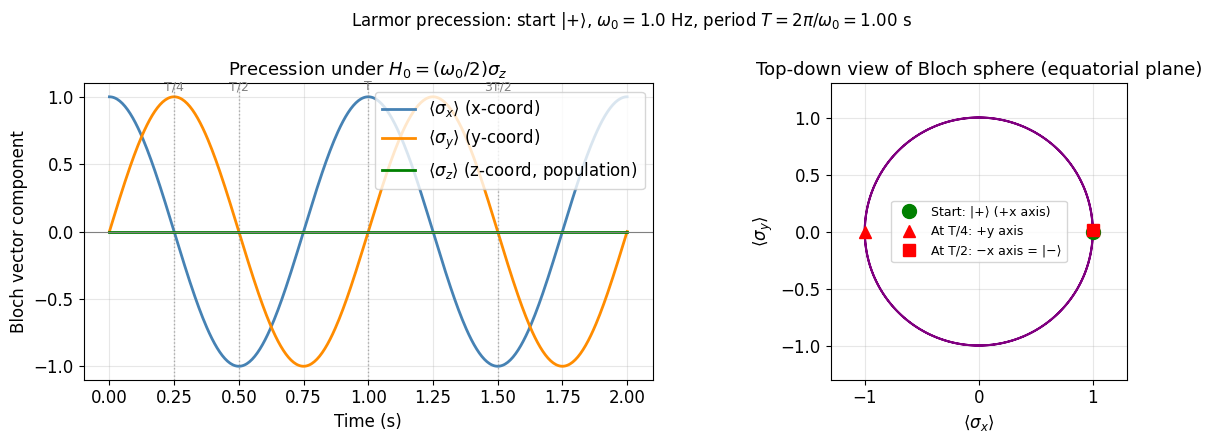


Precession period T = 2π/ω₀ = 1.0000 s
⟨σz⟩ range: min=0.000000, max=0.000000  (constant — no height change)
⟨σx⟩ range: min=-1.0000, max=1.0000  (oscillates)


In [8]:
# ── Qubit precession under H₀ = (ω₀/2)σz ────────────────────────
#
# Physical picture: the qubit in |+⟩ (on the equator, pointing along +x)
# precesses around the z-axis at frequency ω₀.
# The z-component stays constant. The x and y components oscillate.
# This is identical to a gyroscope precessing in a magnetic field.

omega0 = 2 * np.pi * 1.0   # 1 Hz for visualization (real qubits: GHz)
H0 = (omega0 / 2) * sigmaz()

psi0  = (basis(2, 0) + basis(2, 1)).unit()   # |+⟩ — on the equator
T     = 2 * np.pi / omega0                   # one full precession period
times = np.linspace(0, 2*T, 400)

result = sesolve(H0, psi0, times)

sx = expect(sigmax(), result.states)
sy = expect(sigmay(), result.states)
sz = expect(sigmaz(), result.states)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: time traces of Bloch components ─────────────────────────
axes[0].plot(times, sx, label=r'$\langle\sigma_x\rangle$ (x-coord)', color='steelblue')
axes[0].plot(times, sy, label=r'$\langle\sigma_y\rangle$ (y-coord)', color='darkorange')
axes[0].plot(times, sz, label=r'$\langle\sigma_z\rangle$ (z-coord, population)', color='green')
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Bloch vector component')
axes[0].set_title(r'Precession under $H_0 = (\omega_0/2)\sigma_z$')
axes[0].legend()

# Mark key times
for t_mark, label in [(T/4, 'T/4'), (T/2, 'T/2'), (T, 'T'), (3*T/2, '3T/2')]:
    axes[0].axvline(t_mark, color='gray', ls=':', lw=1, alpha=0.6)
    axes[0].text(t_mark, 1.05, label, ha='center', fontsize=9, color='gray')

# ── Right: trajectory on equatorial plane (top-down Bloch view) ───
axes[1].plot(sx, sy, color='purple', lw=1.5)
axes[1].plot(sx[0], sy[0], 'go', ms=10, label='Start: |+⟩ (+x axis)', zorder=5)
axes[1].plot(sx[len(sx)//4], sy[len(sy)//4], 'r^', ms=8, label='At T/4: +y axis', zorder=5)
axes[1].plot(sx[len(sx)//2], sy[len(sy)//2], 'rs', ms=8, label='At T/2: −x axis = |−⟩', zorder=5)
circle = plt.Circle((0,0), 1, fill=False, color='gray', ls='--', alpha=0.5)
axes[1].add_patch(circle)
axes[1].set_xlabel(r'$\langle\sigma_x\rangle$')
axes[1].set_ylabel(r'$\langle\sigma_y\rangle$')
axes[1].set_title('Top-down view of Bloch sphere (equatorial plane)')
axes[1].set_aspect('equal')
axes[1].set_xlim(-1.3, 1.3); axes[1].set_ylim(-1.3, 1.3)
axes[1].legend(fontsize=9)

plt.suptitle(
    f'Larmor precession: start |+⟩, $\\omega_0 = {omega0/(2*np.pi):.1f}$ Hz, '
    f'period $T = 2\\pi/\\omega_0 = {T:.2f}$ s',
    fontsize=12
)
plt.tight_layout()
plt.show()

print(f'\nPrecession period T = 2π/ω₀ = {T:.4f} s')
print(f'⟨σz⟩ range: min={sz.min():.6f}, max={sz.max():.6f}  (constant — no height change)')
print(f'⟨σx⟩ range: min={sx.min():.4f}, max={sx.max():.4f}  (oscillates)')

## 1.5 Fidelity — The Central Performance Metric

### Definition

Fidelity measures how close your achieved quantum state is to the desired target state. For a pure target state $|\psi_{\text{target}}\rangle$ and a pure final state $|\psi_{\text{final}}\rangle$:

$$F = |\langle\psi_{\text{target}}|\psi_{\text{final}}\rangle|^2$$

The inner product $\langle\psi_{\text{target}}|\psi_{\text{final}}\rangle$ is the **overlap** between the two states — a complex number whose magnitude measures how similar the states are. Squaring removes the phase and gives a real number in $[0, 1]$.

For mixed states (density matrices), the fidelity is:

$$F(\rho, \sigma) = \left(\text{Tr}\sqrt{\sqrt{\rho}\,\sigma\,\sqrt{\rho}}\right)^2$$

QuTiP's `fidelity()` function computes this correctly for both pure and mixed states.

### Geometric Interpretation

$F = 1$: Perfect. Your state is exactly the target. Bloch vectors are identical.  
$F = 0$: Completely wrong. Your state is orthogonal to the target. Opposite poles on the Bloch sphere.  
$F = 0.5$: The state is at 90° to the target — on the equator when the target is a pole.  

### Why Fidelity Is Everything in Quantum Control

In quantum computing, fidelity is the ultimate benchmark. Fault-tolerant quantum computation requires gate fidelities above a **fault-tolerance threshold** — typically $F > 0.999$ (99.9%) or higher. Below this threshold, error correction cannot keep up with the accumulation of errors.

Your RL agent's objective is to maximize fidelity. Every design choice — pulse shape, amplitude, duration, noise mitigation strategy — is evaluated by whether it improves fidelity.

### From Bukov & Marquardt (2026)

> *"The reward signal encodes a figure of merit that determines the degree to which the task has been solved successfully."*

Fidelity is exactly this figure of merit for quantum control tasks.

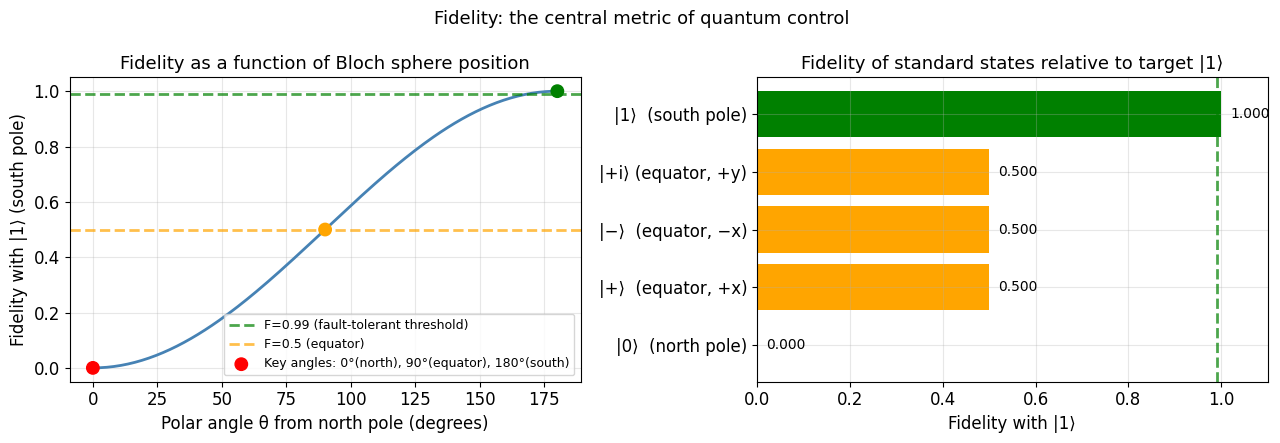

In [9]:
# ── Fidelity as a function of Bloch sphere angle ──────────────────
#
# We fix the target as |1⟩ (south pole) and compute the fidelity of
# states parameterized by the polar angle θ from the north pole.
# θ=0 → |0⟩ (F=0), θ=π/2 → equator (F=0.5), θ=π → |1⟩ (F=1)

target = basis(2, 1)   # |1⟩

thetas = np.linspace(0, np.pi, 200)
fidelities = []
for theta in thetas:
    state = (np.cos(theta/2) * basis(2,0) + np.sin(theta/2) * basis(2,1))
    F = float(fidelity(target, state)**2)
    fidelities.append(F)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Fidelity curve
axes[0].plot(np.degrees(thetas), fidelities, color='steelblue')
axes[0].axhline(0.99, color='green',  ls='--', alpha=0.7, label='F=0.99 (fault-tolerant threshold)')
axes[0].axhline(0.5,  color='orange', ls='--', alpha=0.7, label='F=0.5 (equator)')
axes[0].scatter([0, 90, 180], [0, 0.5, 1.0],
                color=['red','orange','green'], s=80, zorder=5,
                label='Key angles: 0°(north), 90°(equator), 180°(south)')
axes[0].set_xlabel('Polar angle θ from north pole (degrees)')
axes[0].set_ylabel('Fidelity with |1⟩ (south pole)')
axes[0].set_title('Fidelity as a function of Bloch sphere position')
axes[0].legend(fontsize=9)

# Fidelity table for key states
key_states = [
    ('|0⟩  (north pole)',    basis(2, 0)),
    ('|+⟩  (equator, +x)',   (basis(2,0)+basis(2,1)).unit()),
    ('|−⟩  (equator, −x)',   (basis(2,0)-basis(2,1)).unit()),
    ('|+i⟩ (equator, +y)',   (basis(2,0)+1j*basis(2,1)).unit()),
    ('|1⟩  (south pole)',    basis(2, 1)),
]

labels_k = [s[0] for s in key_states]
fids_k   = [float(fidelity(target, s[1])**2) for s in key_states]

bars = axes[1].barh(labels_k, fids_k,
                    color=['tomato','orange','orange','orange','green'])
axes[1].axvline(0.99, color='green', ls='--', alpha=0.7)
axes[1].set_xlabel('Fidelity with |1⟩')
axes[1].set_title('Fidelity of standard states relative to target |1⟩')
axes[1].set_xlim(0, 1.1)
for bar, f in zip(bars, fids_k):
    axes[1].text(f+0.02, bar.get_y()+bar.get_height()/2,
                 f'{f:.3f}', va='center', fontsize=10)

plt.suptitle('Fidelity: the central metric of quantum control', fontsize=13)
plt.tight_layout()
plt.show()

---
# Phase 2 — Driven Qubits, Resonance, and Rabi Oscillations

## 2.1 Adding a Drive: The Control Hamiltonian

### The Full Hamiltonian

To control the qubit — to move its state from $|0\rangle$ toward $|1\rangle$ — you apply an external oscillating field. The full Hamiltonian becomes:

$$H(t) = \underbrace{\frac{\omega_0}{2}\sigma_z}_{\text{free evolution}} + \underbrace{\frac{\Omega}{2}\cos(\omega_d t)\,\sigma_x}_{\text{control drive}}$$

**$\omega_0$** is the qubit's natural frequency — fixed by physics, you cannot change it.  
**$\Omega$** is the drive amplitude — how hard you push. This is your control knob for speed.  
**$\omega_d$** is the drive frequency — how fast the drive oscillates. This is your control knob for resonance.

### The Two Competing Terms

The free Hamiltonian $(\omega_0/2)\sigma_z$ causes precession around z. The drive $(\Omega/2)\cos(\omega_d t)\sigma_x$ tries to rotate the qubit around x. These two compete:

- If $\omega_d \neq \omega_0$: the drive and precession are out of sync. They partially cancel each other. The net effect is small even for large $\Omega$.
- If $\omega_d = \omega_0$: the drive is perfectly synchronized with the precession. Every push adds constructively. Even small $\Omega$ produces large rotations over time.

This synchronization is **resonance** — the single most important concept in quantum control.

### From Koch et al. (2022)

> *"A typical closed quantum control system extends the Schrödinger equation by several control Hamiltonians whose impact is scaled by possibly time-dependent control amplitudes — for instance, $u_x(t)\sigma_x$ for an x-pulse of amplitude $u_x(t)$ on a single qubit."*

Your drive term $\frac{\Omega}{2}\cos(\omega_d t)\sigma_x$ is exactly this structure: $u_x(t) = \frac{\Omega}{2}\cos(\omega_d t)$.

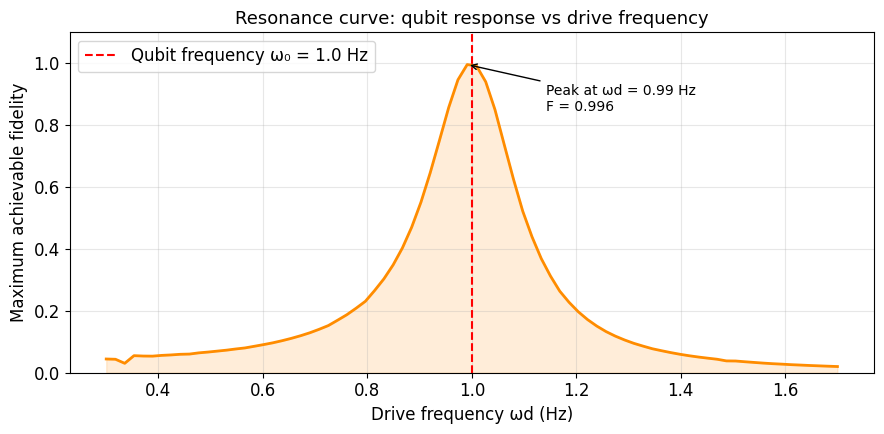

Peak fidelity: 0.9958 at ωd = 0.991 Hz
Qubit natural frequency: 1.000 Hz

Conclusion: maximum response occurs when drive frequency = qubit frequency (resonance).


In [11]:
# ── Resonance: drive frequency sweep ──────────────────────────────
#
# For each drive frequency, we run the simulation and record the
# maximum fidelity achieved with |1⟩. The resonance peak should
# appear at ωd = ω₀.

omega0 = 2 * np.pi * 1.0
Omega  = 2 * np.pi * 0.2   # weak drive to make resonance sharp
T_sim  = 15.0
target = basis(2, 1)
psi0   = basis(2, 0)

drive_freqs = np.linspace(2*np.pi*0.3, 2*np.pi*1.7, 80)
max_fids = []

H0 = (omega0 / 2) * sigmaz()
H1 = (Omega  / 2) * sigmax()

def drive_coeff(t, args):
    return np.cos(args['od'] * t)

for od in drive_freqs:
    H = [H0, [H1, drive_coeff]]
    t = np.linspace(0, T_sim, 500)
    res = sesolve(H, psi0, t, args={'od': od})
    fids = [float(fidelity(target, s)**2) for s in res.states]
    max_fids.append(max(fids))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(drive_freqs/(2*np.pi), max_fids, color='darkorange', lw=2)
ax.axvline(omega0/(2*np.pi), color='red', ls='--', lw=1.5,
           label=f'Qubit frequency ω₀ = {omega0/(2*np.pi):.1f} Hz')
ax.fill_between(drive_freqs/(2*np.pi), max_fids, alpha=0.15, color='darkorange')
ax.set_xlabel('Drive frequency ωd (Hz)')
ax.set_ylabel('Maximum achievable fidelity')
ax.set_title('Resonance curve: qubit response vs drive frequency')
ax.set_ylim(0, 1.1)
ax.legend()

# Annotate the peak
peak_idx = np.argmax(max_fids)
ax.annotate(f'Peak at ωd = {drive_freqs[peak_idx]/(2*np.pi):.2f} Hz\nF = {max_fids[peak_idx]:.3f}',
            xy=(drive_freqs[peak_idx]/(2*np.pi), max_fids[peak_idx]),
            xytext=(drive_freqs[peak_idx]/(2*np.pi)+0.15, max_fids[peak_idx]-0.15),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.show()

print(f'Peak fidelity: {max(max_fids):.4f} at ωd = {drive_freqs[np.argmax(max_fids)]/(2*np.pi):.3f} Hz')
print(f'Qubit natural frequency: {omega0/(2*np.pi):.3f} Hz')
print('\nConclusion: maximum response occurs when drive frequency = qubit frequency (resonance).')

## 2.2 Rabi Oscillations — The Heartbeat of Quantum Control

### What Are Rabi Oscillations?

When you apply a resonant drive ($\omega_d = \omega_0$) to a qubit, the qubit does not just flip once and stay in $|1\rangle$. It **oscillates continuously** between $|0\rangle$ and $|1\rangle$ at a rate determined by the drive amplitude. These oscillations are called **Rabi oscillations**, named after Isidor Rabi who discovered them experimentally in 1938 using molecular beams in magnetic fields.

### The Rabi Frequency

On resonance, the effective Hamiltonian (in the rotating frame, see Section 2.3) is simply:

$$H_{\text{eff}} = \frac{\Omega}{2}\sigma_x$$

This generates a rotation around the x-axis at angular speed $\Omega$. The qubit state oscillates between $|0\rangle$ and $|1\rangle$ at the **Rabi frequency** $\Omega_R = \Omega$.

The population of the excited state oscillates as:

$$P_{|1\rangle}(t) = \sin^2\left(\frac{\Omega t}{2}\right)$$

### The π-Pulse — The Fundamental Gate

A **π-pulse** is a resonant drive applied for exactly the duration:

$$T_\pi = \frac{\pi}{\Omega}$$

At this time, the qubit has completed exactly half a Rabi oscillation: it goes from $|0\rangle$ to $|1\rangle$. This is a perfect bit flip — equivalent to the X gate in quantum computing.

A **π/2-pulse** is applied for $T_{\pi/2} = \pi/(2\Omega)$. It takes the qubit from a pole to the equator — creating an equal superposition. This is the Hadamard gate.

**These two pulses are the primitive operations of all single-qubit quantum computing.**

### Why Rabi Oscillations Matter for Your Project

The hand-designed π-pulse baseline in your research project is simply a resonant drive applied for duration $T_\pi = \pi/\Omega$. It is the textbook solution — optimal in the noise-free case. Under decoherence, it may not be optimal because:

1. Longer pulses give decoherence more time to act.
2. The simple timing formula assumes perfect model knowledge.
3. The pulse shape (constant amplitude) may not be optimal under noise.

Your RL agent will learn whether a different strategy — variable amplitude, adaptive timing — can do better.

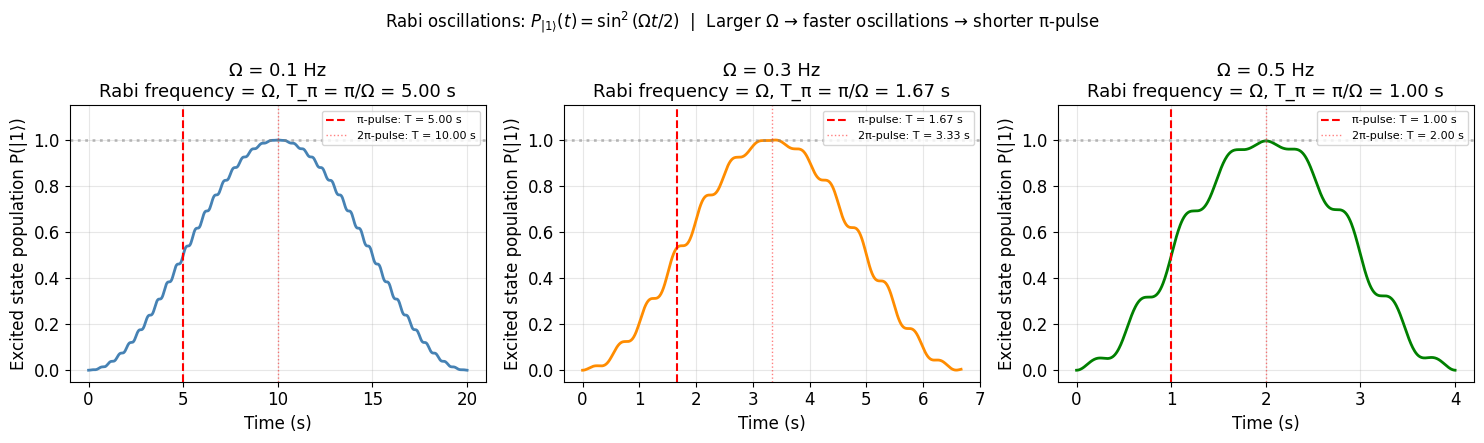

Key relationship:
  Ω = 0.1 Hz  →  T_π = π/Ω = 5.0000 s
  Ω = 0.3 Hz  →  T_π = π/Ω = 1.6667 s
  Ω = 0.5 Hz  →  T_π = π/Ω = 1.0000 s


In [10]:
# ── Rabi oscillations: comparing different drive amplitudes ───────

omega0 = 2 * np.pi * 1.0
psi0   = basis(2, 0)
target = basis(2, 1)

amplitudes = [0.1, 0.3, 0.5]
colors     = ['steelblue', 'darkorange', 'green']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, Omega, color in zip(axes, amplitudes, colors):
    T_pi = np.pi / (2 * np.pi * Omega)   # π-pulse duration
    T_total = 4 * T_pi                    # show 2 full Rabi cycles
    times = np.linspace(0, T_total, 600)

    H0 = (omega0 / 2) * sigmaz()
    H1 = (2 * np.pi * Omega / 2) * sigmax()
    def dc(t, args): return np.cos(args['od'] * t)
    H = [H0, [H1, dc]]

    res = sesolve(H, psi0, times, args={'od': omega0})
    sz = expect(sigmaz(), res.states)
    # Convert sz to excited state population: P(|1>) = (1 - <sz>) / 2
    P1 = (1 - np.array(sz)) / 2

    ax.plot(times, P1, color=color, lw=2)
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
    ax.axvline(T_pi, color='red', ls='--', lw=1.5,
               label=f'π-pulse: T = {T_pi:.2f} s')
    ax.axvline(2*T_pi, color='red', ls=':', lw=1, alpha=0.5,
               label=f'2π-pulse: T = {2*T_pi:.2f} s')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Excited state population P(|1⟩)')
    ax.set_title(f'Ω = {Omega} Hz\nRabi frequency = Ω, T_π = π/Ω = {T_pi:.2f} s')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=8)

plt.suptitle(
    r'Rabi oscillations: $P_{|1\rangle}(t) = \sin^2(\Omega t/2)$  |  '
    'Larger Ω → faster oscillations → shorter π-pulse',
    fontsize=12
)
plt.tight_layout()
plt.show()

print('Key relationship:')
for Omega in amplitudes:
    T_pi = np.pi / (2*np.pi*Omega)
    print(f'  Ω = {Omega} Hz  →  T_π = π/Ω = {T_pi:.4f} s')

## 2.3 The Rotating Frame — The Engineer's Perspective

### The Problem With the Lab Frame

In the lab frame, the qubit simultaneously precesses around z at $\omega_0$ (fast) and is driven toward $|1\rangle$ by the control pulse (slow). For a real superconducting qubit at 5 GHz, the precession is $5 \times 10^9$ revolutions per second. The control-induced rotation is much slower — perhaps thousands of revolutions per second. Visualizing or computing the dynamics in this frame is numerically expensive and geometrically confusing.

### The Solution: Change Reference Frame

The rotating frame (also called the interaction picture) is a mathematical transformation where we "ride along" with the fast precession. We transform the state:

$$|\tilde{\psi}(t)\rangle = e^{+i\omega_d t \sigma_z / 2}|\psi(t)\rangle$$

This transformation removes the fast oscillation at $\omega_d$ from the state. The effective Hamiltonian in the rotating frame becomes (after the **rotating wave approximation**, dropping terms oscillating at $2\omega_d$ which average to zero):

$$\tilde{H} = \frac{\Delta}{2}\sigma_z + \frac{\Omega}{2}\sigma_x$$

where $\Delta = \omega_0 - \omega_d$ is the **detuning** — how far the drive is from resonance.

**On resonance** ($\omega_d = \omega_0$, so $\Delta = 0$):

$$\tilde{H}_{\text{res}} = \frac{\Omega}{2}\sigma_x$$

Just a rotation around x at rate $\Omega$. Clean, simple, exactly what you want to see. The π-pulse timing formula $T_\pi = \pi/\Omega$ comes directly from this.

### Physical Interpretation

The rotating frame is not just a mathematical trick — it has physical content. Real quantum engineers always design and think about pulses in the rotating frame. The amplitude $\Omega$ and the detuning $\Delta$ are the two parameters they tune. Modern microwave control electronics for superconducting qubits natively generate pulses in the rotating frame (called **baseband pulses**).

### Detuning and Its Effect

Off resonance ($\Delta \neq 0$), the effective Hamiltonian has both $\sigma_z$ and $\sigma_x$ terms. The rotation axis is tilted away from the x-axis toward z. The maximum excited state population is:

$$P_{|1\rangle}^{\text{max}} = \frac{\Omega^2}{\Omega^2 + \Delta^2}$$

This is why off-resonance drives cannot fully flip the qubit: the tilt toward z means the rotation never reaches the south pole.

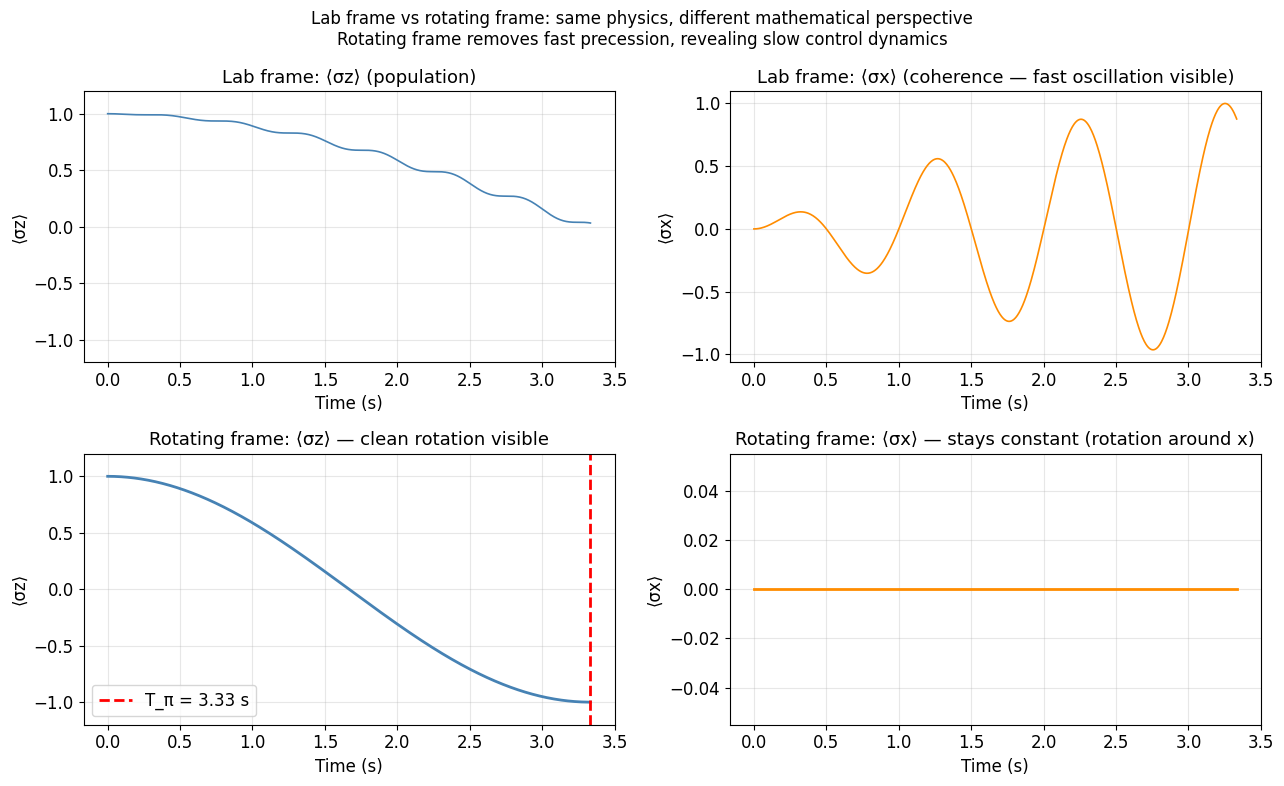

Final fidelity — lab frame: 0.4840
Final fidelity — rotating frame: 1.0000
(Should be the same — same physics, different perspective)


In [12]:
# ── Lab frame vs rotating frame comparison ────────────────────────

omega0 = 2 * np.pi * 1.0
Omega  = 2 * np.pi * 0.15
psi0   = basis(2, 0)
T_rabi = np.pi / Omega   # one π-pulse
times  = np.linspace(0, T_rabi, 800)

# ── Lab frame simulation ──────────────────────────────────────────
H0 = (omega0 / 2) * sigmaz()
H1 = (Omega  / 2) * sigmax()
def dc(t, args): return np.cos(args['od'] * t)
H_lab = [H0, [H1, dc]]
res_lab = sesolve(H_lab, psi0, times, args={'od': omega0})

# ── Rotating frame simulation ─────────────────────────────────────
# On resonance, rotating frame Hamiltonian is just (Omega/2)*sigma_x
H_rot = (Omega / 2) * sigmax()
res_rot = sesolve(H_rot, psi0, times)

sz_lab = expect(sigmaz(), res_lab.states)
sx_lab = expect(sigmax(), res_lab.states)
sz_rot = expect(sigmaz(), res_rot.states)
sx_rot = expect(sigmax(), res_rot.states)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Lab frame sz
axes[0,0].plot(times, sz_lab, color='steelblue', lw=1.2)
axes[0,0].set_title('Lab frame: ⟨σz⟩ (population)')
axes[0,0].set_xlabel('Time (s)'); axes[0,0].set_ylabel('⟨σz⟩')
axes[0,0].set_ylim(-1.2, 1.2)

# Lab frame sx
axes[0,1].plot(times, sx_lab, color='darkorange', lw=1.2)
axes[0,1].set_title('Lab frame: ⟨σx⟩ (coherence — fast oscillation visible)')
axes[0,1].set_xlabel('Time (s)'); axes[0,1].set_ylabel('⟨σx⟩')

# Rotating frame sz
axes[1,0].plot(times, sz_rot, color='steelblue', lw=2)
axes[1,0].set_title('Rotating frame: ⟨σz⟩ — clean rotation visible')
axes[1,0].set_xlabel('Time (s)'); axes[1,0].set_ylabel('⟨σz⟩')
axes[1,0].set_ylim(-1.2, 1.2)
axes[1,0].axvline(T_rabi, color='red', ls='--', label=f'T_π = {T_rabi:.2f} s')
axes[1,0].legend()

# Rotating frame sx
axes[1,1].plot(times, sx_rot, color='darkorange', lw=2)
axes[1,1].set_title('Rotating frame: ⟨σx⟩ — stays constant (rotation around x)')
axes[1,1].set_xlabel('Time (s)'); axes[1,1].set_ylabel('⟨σx⟩')

plt.suptitle(
    'Lab frame vs rotating frame: same physics, different mathematical perspective\n'
    'Rotating frame removes fast precession, revealing slow control dynamics',
    fontsize=12
)
plt.tight_layout()
plt.show()

# Verify both give same final fidelity
F_lab = float(fidelity(basis(2,1), res_lab.states[-1])**2)
F_rot = float(fidelity(basis(2,1), res_rot.states[-1])**2)
print(f'Final fidelity — lab frame: {F_lab:.4f}')
print(f'Final fidelity — rotating frame: {F_rot:.4f}')
print('(Should be the same — same physics, different perspective)')

---
# Phase 3 — Pulse Engineering and Spectral Intuition

## 3.1 Pulse Shapes and the Frequency Domain

### Why Pulse Shape Matters

So far we have used a constant-amplitude drive (a rectangular or 'square' pulse). In practice, the shape of the pulse in time determines its **frequency content** — which frequencies are present in the control field and at what amplitudes.

This matters because:

1. **Leakage:** Real qubits are not perfect two-level systems. Higher energy levels exist. A pulse with broad frequency content can accidentally excite these levels, taking population out of the computational subspace. This is called leakage.
2. **Selectivity:** When multiple qubits are coupled, a pulse must drive one qubit without affecting others. A spectrally narrow pulse achieves this; a broad pulse does not.
3. **Off-resonance effects:** Even in a two-level system, frequency components far from $\omega_0$ are ineffective and introduce phase errors.

### The Fourier Relationship

The Fourier transform of a pulse envelope $\Omega(t)$ gives its frequency spectrum:

$$\tilde{\Omega}(\nu) = \int_{-\infty}^{\infty} \Omega(t)\, e^{-2\pi i \nu t}\, dt$$

Key relationships:

| Pulse shape | Time domain | Frequency domain |
|------------|-------------|------------------|
| Square (rectangular) | Flat, abrupt edges | Sinc function — broad, oscillating sidebands |
| Gaussian | Smooth bell curve | Gaussian — concentrated, no sidebands |
| DRAG | Gaussian + derivative correction | Gaussian with leakage cancelled |

The **uncertainty principle** applies here: a short pulse in time has broad frequency content. You cannot simultaneously have a short pulse (fast gate) and a spectrally pure pulse (no off-resonance effects). This is a fundamental trade-off in pulse engineering.

### From Koch et al. (2022)

> *"Optimal control theory provides a toolbox for devising pulse shapes that accomplish given tasks in the best way possible, including satisfying constraints imposed by the devices at hand."*

The pulse shape is the primary design variable in quantum control engineering.

In [ ]:
# ── Square vs Gaussian pulse: time and frequency domain ───────────

T_gate = 5.0    # pulse duration
dt     = 0.01
times  = np.arange(0, T_gate, dt)
N      = len(times)

# ── Square pulse ──────────────────────────────────────────────────
A_sq = 1.0
pulse_sq = A_sq * np.ones(N)

# ── Gaussian pulse ────────────────────────────────────────────────
# Amplitude chosen so area = π (implements a π-rotation)
sigma    = T_gate / 6
t_center = T_gate / 2
pulse_gauss_raw = np.exp(-0.5 * ((times - t_center) / sigma)**2)
area_gauss = trapezoid(pulse_gauss_raw, times)
# Normalize square pulse area to match gaussian area for fair comparison
pulse_sq_norm = pulse_sq * (area_gauss / trapezoid(pulse_sq, times))
pulse_gauss   = pulse_gauss_raw  # already normalized to same area

# ── Frequency domain ──────────────────────────────────────────────
freqs   = fftfreq(N, dt)
pos_idx = freqs > 0
spec_sq    = np.abs(np.fft.fft(pulse_sq_norm))[pos_idx]
spec_gauss = np.abs(np.fft.fft(pulse_gauss))[pos_idx]
f_pos = freqs[pos_idx]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Time domain
axes[0,0].plot(times, pulse_sq_norm, color='steelblue', lw=2)
axes[0,0].fill_between(times, pulse_sq_norm, alpha=0.2, color='steelblue')
axes[0,0].set_title('Square pulse (time domain)')
axes[0,0].set_xlabel('Time (s)'); axes[0,0].set_ylabel('Amplitude')
axes[0,0].set_ylim(-0.1, 1.2)

axes[0,1].plot(times, pulse_gauss, color='darkorange', lw=2)
axes[0,1].fill_between(times, pulse_gauss, alpha=0.2, color='darkorange')
axes[0,1].set_title('Gaussian pulse (time domain)')
axes[0,1].set_xlabel('Time (s)'); axes[0,1].set_ylabel('Amplitude')
axes[0,1].set_ylim(-0.1, 1.2)

# Frequency domain
axes[1,0].plot(f_pos, spec_sq/spec_sq.max(), color='steelblue', lw=2)
axes[1,0].set_title('Square pulse spectrum — broad, oscillating sidebands')
axes[1,0].set_xlabel('Frequency (Hz)'); axes[1,0].set_ylabel('Normalized amplitude')
axes[1,0].set_xlim(0, 3)
axes[1,0].axvline(1.0/T_gate, color='red', ls='--', alpha=0.6,
                   label=f'1/T = {1/T_gate:.2f} Hz')
axes[1,0].legend(fontsize=9)

axes[1,1].plot(f_pos, spec_gauss/spec_gauss.max(), color='darkorange', lw=2)
axes[1,1].set_title('Gaussian pulse spectrum — narrow, concentrated near DC')
axes[1,1].set_xlabel('Frequency (Hz)'); axes[1,1].set_ylabel('Normalized amplitude')
axes[1,1].set_xlim(0, 3)
axes[1,1].axvline(1.0/(2*np.pi*sigma), color='red', ls='--', alpha=0.6,
                   label=f'1/(2πσ) = {1/(2*np.pi*sigma):.2f} Hz')
axes[1,1].legend(fontsize=9)

plt.suptitle(
    'Pulse shape determines spectral content\n'
    'Square → broad spectrum (leakage risk)    Gaussian → narrow spectrum (selective)',
    fontsize=12
)
plt.tight_layout()
plt.show()

# Bandwidth comparison
sq_bw    = f_pos[spec_sq > spec_sq.max()*0.5].max() - f_pos[spec_sq > spec_sq.max()*0.5].min()
gauss_bw = f_pos[spec_gauss > spec_gauss.max()*0.5].max() - f_pos[spec_gauss > spec_gauss.max()*0.5].min()
print(f'Square pulse bandwidth (at half max):  {sq_bw:.3f} Hz')
print(f'Gaussian pulse bandwidth (at half max): {gauss_bw:.3f} Hz')
print(f'Ratio: square is {sq_bw/gauss_bw:.1f}× broader than Gaussian')

In [ ]:
# ── Fidelity landscape: amplitude vs duration heatmap ─────────────
#
# This is the optimization landscape your RL agent navigates.
# Each point (Ω, T) is a possible pulse. Color = fidelity achieved.

omega0 = 2 * np.pi * 1.0
psi0   = basis(2, 0)
target = basis(2, 1)

n_pts      = 35
amplitudes = np.linspace(0.05, 1.5, n_pts) * 2 * np.pi
durations  = np.linspace(0.1, 5.0, n_pts)

fid_map = np.zeros((n_pts, n_pts))

H0 = (omega0/2) * sigmaz()
def dc(t, args): return np.cos(args['od'] * t)

for i, T in enumerate(durations):
    for j, Omega in enumerate(amplitudes):
        H1 = (Omega/2) * sigmax()
        H  = [H0, [H1, dc]]
        t  = np.linspace(0, T, max(30, int(T/0.05)))
        res = sesolve(H, psi0, t, args={'od': omega0})
        fid_map[i, j] = float(fidelity(target, res.states[-1])**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].contourf(amplitudes/(2*np.pi), durations, fid_map,
                       levels=50, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[0], label='Fidelity')
# Overlay the analytical π-pulse line: T = π/Ω
omega_line = np.linspace(amplitudes[0], amplitudes[-1], 200)
T_pi_line  = np.pi / omega_line
valid = T_pi_line <= durations[-1]
axes[0].plot(omega_line[valid]/(2*np.pi), T_pi_line[valid],
             color='white', lw=2, ls='--', label='T = π/Ω (analytical π-pulse)')
axes[0].set_xlabel('Drive amplitude Ω (Hz)')
axes[0].set_ylabel('Pulse duration T (s)')
axes[0].set_title('Fidelity landscape: |0⟩ → |1⟩')
axes[0].legend(fontsize=9)

# Slice at fixed Omega
fixed_j = n_pts // 2
axes[1].plot(durations, fid_map[:, fixed_j], color='steelblue', lw=2)
axes[1].axhline(0.99, color='green', ls='--', label='F = 0.99')
T_pi_fixed = np.pi / amplitudes[fixed_j]
axes[1].axvline(T_pi_fixed, color='red', ls='--',
                label=f'T_π = {T_pi_fixed:.2f} s')
axes[1].set_xlabel('Pulse duration T (s)')
axes[1].set_ylabel('Fidelity')
axes[1].set_title(f'Fidelity vs duration at Ω = {amplitudes[fixed_j]/(2*np.pi):.2f} Hz')
axes[1].legend(fontsize=9)

plt.suptitle('The optimization landscape your RL agent navigates', fontsize=13)
plt.tight_layout()
plt.show()

---
# Phase 4 — Open Quantum Systems and Decoherence

## 4.1 Why Real Qubits Are Never Isolated

### The Idealization We Have Been Using

Everything in Phases 1–3 assumed a **closed quantum system**: the qubit evolves perfectly according to the Schrödinger equation, retaining all information about its state indefinitely. This is a powerful idealization for building intuition, but it is physically false.

Every real quantum system — no matter how carefully engineered — is coupled to its environment. The environment might be:
- Thermal phonons in the substrate material
- Electromagnetic fluctuations from nearby electronics
- Stray magnetic fields
- Charge noise in the insulating layers
- Interactions with other qubits

This coupling has two irreversible consequences: **energy relaxation** and **dephasing**. Together, these constitute **decoherence** — the process by which a quantum state loses its quantum character and behaves increasingly like a classical statistical mixture.

### Why Decoherence Is Fundamental, Not Just Engineering

Decoherence is not a problem to be eliminated by better engineering. It is a consequence of quantum mechanics interacting with thermodynamics. A qubit in an excited state has more energy than the thermal equilibrium state. According to the second law of thermodynamics, energy flows from the qubit to the environment until equilibrium is reached. This flow is irreversible.

The only engineering question is **how fast** it happens — characterized by the timescales $T_1$ and $T_2$ — and whether your quantum computation can complete before decoherence degrades the state below the fault-tolerance threshold.

## 4.2 The Two Decoherence Processes

### T₁ — Energy Relaxation

**What it is:** The excited state $|1\rangle$ spontaneously loses its energy to the environment and returns to the ground state $|0\rangle$.

**Physical mechanism:** The qubit couples to environmental modes (photons, phonons) that absorb the qubit's energy quantum. This is identical to spontaneous emission from an excited atom.

**Effect on the Bloch sphere:** The Bloch vector is pulled toward the north pole ($|0\rangle$) at rate $\gamma_1 = 1/T_1$, regardless of its current position. The $z$-component evolves as:
$$\langle\sigma_z\rangle(t) = 1 - (1 - \langle\sigma_z\rangle(0))\,e^{-t/T_1}$$

**What it destroys:** Population. If the qubit is in $|1\rangle$, it decays to $|0\rangle$.

### T₂ — Dephasing (Total)

**What it is:** The phase coherence between $|0\rangle$ and $|1\rangle$ — the off-diagonal elements of the density matrix — is randomly scrambled by environmental fluctuations.

**Physical mechanism:** Random fluctuations in the qubit's energy gap (from charge noise, flux noise, etc.) cause the precession frequency to fluctuate. Different experimental runs accumulate different random phases, and the ensemble average of the coherences decays to zero.

**Effect on the Bloch sphere:** The Bloch vector shrinks toward the z-axis. The $x$ and $y$ components decay as:
$$\langle\sigma_x\rangle(t) = \langle\sigma_x\rangle(0)\,e^{-t/T_2}, \quad \langle\sigma_y\rangle(t) = \langle\sigma_y\rangle(0)\,e^{-t/T_2}$$

**What it destroys:** Coherence — the phase relationships that superposition depends on.

### The T₁-T₂ Relationship

T₁ relaxation also contributes to dephasing — because if the qubit randomly flips from $|1\rangle$ to $|0\rangle$, the phase is also randomized. The total dephasing rate is:

$$\frac{1}{T_2} = \frac{1}{2T_1} + \frac{1}{T_\phi}$$

where $T_\phi$ is the **pure dephasing time** from phase noise alone. This means:

$$T_2 \leq 2T_1$$

T₂ is always shorter than or equal to twice T₁. In practice T₂ < 2T₁ because pure dephasing is always present. For superconducting qubits, typical values are T₁ ~ 100–500 μs and T₂ ~ 50–300 μs.

## 4.3 The Density Matrix — Describing Mixed States

### Why State Vectors Are No Longer Sufficient

When a qubit interacts with an environment, the qubit-environment system forms a joint quantum state. From the qubit's perspective alone, it is in a **statistical mixture** of quantum states — we cannot describe it with a single state vector $|\psi\rangle$. We need the **density matrix** $\rho$.

For a qubit, $\rho$ is a $2\times 2$ complex Hermitian matrix with trace 1:

$$\rho = \begin{pmatrix} \rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11} \end{pmatrix}$$

- $\rho_{00}$ = probability of finding qubit in $|0\rangle$
- $\rho_{11}$ = probability of finding qubit in $|1\rangle$ ($\rho_{00} + \rho_{11} = 1$)
- $\rho_{01} = \rho_{10}^*$ = **coherences** — encode the quantum superposition

The Bloch vector components are:
$$\langle\sigma_x\rangle = 2\,\text{Re}(\rho_{01}), \quad \langle\sigma_y\rangle = 2\,\text{Im}(\rho_{01}), \quad \langle\sigma_z\rangle = \rho_{00} - \rho_{11}$$

A **pure state** has $\text{Tr}(\rho^2) = 1$ — the Bloch vector has unit length, on the sphere surface.  
A **mixed state** has $\text{Tr}(\rho^2) < 1$ — the Bloch vector is inside the sphere.

Decoherence moves the state from the surface inward. A fully decohered qubit is described by the maximally mixed state $\rho = \frac{1}{2}I$ — the center of the sphere, no quantum coherence whatsoever.

## 4.4 The Lindblad Master Equation

### The Equation of Motion for Open Quantum Systems

The generalization of the Schrödinger equation to open quantum systems is the **Gorini-Kossakowski-Sudarshan-Lindblad (GKSL) master equation**, universally called the **Lindblad equation**:

$$\frac{d\rho}{dt} = -i[H, \rho] + \sum_k \left( L_k \rho L_k^\dagger - \frac{1}{2}L_k^\dagger L_k \rho - \frac{1}{2}\rho L_k^\dagger L_k \right)$$

**Part 1:** $-i[H, \rho]$ is the **coherent part** — identical to the Schrödinger equation rewritten for density matrices. It generates unitary evolution from the Hamiltonian.

**Part 2:** The sum is the **dissipator** — it represents incoherent, irreversible environmental effects. Each $L_k$ is a **Lindblad operator** (or collapse operator) representing one physical noise channel.

For your qubit, the two Lindblad operators are:

$$L_1 = \sqrt{\gamma_1}\,\sigma_- \quad \text{(T₁ energy relaxation)}$$
$$L_2 = \sqrt{\gamma_\phi}\,\sigma_z \quad \text{(pure dephasing)}$$

where:
- $\sigma_- = (\sigma_x - i\sigma_y)/2$ is the lowering operator: it maps $|1\rangle \to |0\rangle$
- $\gamma_1 = 1/T_1$ is the energy relaxation rate
- $\gamma_\phi = 1/(2T_2) - 1/(4T_1)$ is the pure dephasing rate

In QuTiP, you solve the Lindblad equation with `mesolve()` instead of `sesolve()`, passing the collapse operators as `c_ops`.

### From Koch et al. (2022)

> *"Open systems with permanent noise are not exactly controllable. However, generic finite dimensional open quantum systems with Hamiltonian controls are accessible."*

This is the key insight: decoherence does not make quantum control impossible, it makes it harder. You can still reach the target state — but you must do so before the environment destroys the coherence you need.

In [ ]:
# ── Decoherence: T1 and T2 effects on a driven qubit ─────────────

omega0 = 2 * np.pi * 1.0
Omega  = 2 * np.pi * 0.4
T1, T2 = 8.0, 4.0

# Compute Lindblad rates from T1 and T2
gamma1    = 1.0 / T1
gamma_phi = 1.0/(2*T2) - 1.0/(4*T1)   # pure dephasing rate

c_ops = [
    np.sqrt(gamma1)    * sigmam(),   # T1: energy relaxation |1>→|0>
    np.sqrt(gamma_phi) * sigmaz(),   # T2: pure dephasing
]

psi0   = basis(2, 0)
target = basis(2, 1)
times  = np.linspace(0, 20.0, 800)

H0 = (omega0/2) * sigmaz()
H1 = (Omega /2) * sigmax()
def dc(t, args): return np.cos(args['od']*t)
H = [H0, [H1, dc]]

res_clean = sesolve(H, psi0, times, args={'od': omega0})
res_noisy = mesolve(H, psi0, times, c_ops=c_ops, args={'od': omega0})

sz_c = expect(sigmaz(), res_clean.states)
sz_n = expect(sigmaz(), res_noisy.states)
sx_c = expect(sigmax(), res_clean.states)
sx_n = expect(sigmax(), res_noisy.states)
fid_c = [float(fidelity(target, s)**2) for s in res_clean.states]
fid_n = [float(fidelity(target, s)**2) for s in res_noisy.states]

fig, axes = plt.subplots(3, 1, figsize=(11, 11))

# Plot 1: Population (sz)
axes[0].plot(times, sz_c, lw=2, color='steelblue', label='No noise')
axes[0].plot(times, sz_n, lw=2, ls='--', color='tomato',
             label=f'T₁={T1}s, T₂={T2}s')
axes[0].axhline(-1, color='gray', ls=':', alpha=0.5, label='|1⟩ (south pole)')
axes[0].axhline( 1, color='gray', ls='-.', alpha=0.5, label='|0⟩ (north pole)')
axes[0].set_ylabel('⟨σz⟩  (population, height on Bloch sphere)')
axes[0].set_title(
    'T₁ effect: Rabi oscillations decay toward ground state\n'
    '⟨σz⟩ drifts toward +1 as energy is lost to environment'
)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_ylim(-1.3, 1.3)

# Plot 2: Coherence (sx)
axes[1].plot(times, sx_c, lw=2, color='steelblue', label='No noise')
axes[1].plot(times, sx_n, lw=2, ls='--', color='tomato',
             label=f'T₁={T1}s, T₂={T2}s')
# T2 envelope
T2_env = np.exp(-times/T2)
axes[1].plot(times, T2_env, color='purple', lw=1.5, ls=':',
             label=f'e^(-t/T₂) envelope (T₂={T2}s)')
axes[1].plot(times, -T2_env, color='purple', lw=1.5, ls=':')
axes[1].set_ylabel('⟨σx⟩  (coherence, equatorial component)')
axes[1].set_title(
    'T₂ effect: coherence envelope decays exponentially\n'
    'Off-diagonal density matrix elements → 0, superposition destroyed'
)
axes[1].legend(loc='upper right', fontsize=9)

# Plot 3: Fidelity
axes[2].plot(times, fid_c, lw=2, color='steelblue', label='No noise')
axes[2].plot(times, fid_n, lw=2, ls='--', color='tomato',
             label=f'T₁={T1}s, T₂={T2}s')
axes[2].axhline(0.99, color='green', ls=':', alpha=0.7, label='F=0.99 threshold')
# Find first peak in noisy fidelity
fid_n_arr = np.array(fid_n)
from scipy.signal import find_peaks
peaks, _ = find_peaks(fid_n_arr, height=0.3, distance=20)
if len(peaks) > 0:
    axes[2].scatter(times[peaks], fid_n_arr[peaks],
                    color='red', s=50, zorder=5, label='Peaks (optimal pulse stops)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Fidelity with |1⟩')
axes[2].set_title(
    'Fidelity peaks degrade under noise\n'
    'Each peak is a moment when the π-pulse could stop — earlier is better'
)
axes[2].legend(loc='upper right', fontsize=9)
axes[2].set_ylim(-0.05, 1.1)

plt.suptitle(
    f'Open quantum system: driven qubit under T₁={T1}s, T₂={T2}s decoherence\n'
    'Same drive, completely different outcome — decoherence changes everything',
    fontsize=12
)
plt.tight_layout()
plt.show()

# Summary numbers
print(f'Lindblad rates:')
print(f'  γ₁ = 1/T₁ = {gamma1:.4f} s⁻¹  (energy relaxation)')
print(f'  γφ = {gamma_phi:.4f} s⁻¹  (pure dephasing)')
print(f'  Check: 1/T₂ = {1/T2:.4f} = γ₁/2 + γφ = {gamma1/2 + gamma_phi:.4f}')
print()
if len(peaks) > 0:
    print(f'First fidelity peak (noisy): F = {fid_n_arr[peaks[0]]:.4f} at t = {times[peaks[0]]:.2f} s')
    print(f'Optimal pulse stops here to preserve maximum fidelity before further decoherence')

In [ ]:
# ── Density matrix evolution: visualizing decoherence ─────────────
#
# We snapshot the density matrix at key moments during noisy evolution
# and show how the off-diagonal elements (coherences) decay.

omega0 = 2 * np.pi * 1.0
Omega  = 2 * np.pi * 0.3
T1, T2 = 6.0, 3.0
gamma1    = 1.0/T1
gamma_phi = 1.0/(2*T2) - 1.0/(4*T1)
c_ops = [np.sqrt(gamma1)*sigmam(), np.sqrt(gamma_phi)*sigmaz()]

psi0  = (basis(2,0) + basis(2,1)).unit()   # start in superposition |+>
T_pi  = np.pi / Omega
snapshot_times = [0, T_pi/4, T_pi/2, T_pi, 2*T_pi, 5*T_pi]
all_times = np.linspace(0, max(snapshot_times), 400)

H0 = (omega0/2)*sigmaz()
# No drive — just watch natural decoherence from |+>
res = mesolve(H0, psi0, all_times, c_ops=c_ops)

# Extract states at snapshot times
snap_states = []
for ts in snapshot_times:
    idx = np.argmin(np.abs(all_times - ts))
    snap_states.append(res.states[idx])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, state, ts in zip(axes, snap_states, snapshot_times):
    rho = state.full()
    # Plot real parts (imaginary parts are small for this initial state)
    data = np.abs(rho)  # show magnitude of density matrix elements
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=0.5, aspect='auto')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['|0⟩','|1⟩']); ax.set_yticklabels(['⟨0|','⟨1|'])
    # Annotate with values
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center',
                    fontsize=11, color='white' if data[i,j] > 0.3 else 'black')
    # Labels
    sz_val = float(expect(sigmaz(), state))
    coh = abs(rho[0,1])
    ax.set_title(f't = {ts:.2f} s\n'
                 f'⟨σz⟩ = {sz_val:.3f},  coherence = {coh:.3f}',
                 fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(
    f'Density matrix |ρ| evolving under decoherence (start: |+⟩, T₁={T1}s, T₂={T2}s)\n'
    'Off-diagonal elements (coherences) decay faster than diagonal (populations)',
    fontsize=12
)
plt.tight_layout()
plt.show()

In [ ]:
# ── The key trade-off: pulse duration vs fidelity under noise ─────
#
# This is the central engineering problem your RL agent solves.
# Longer pulse → more precise rotation BUT more decoherence exposure.
# Shorter pulse → less decoherence BUT less precision.
# There is an optimal duration that balances these two effects.

omega0 = 2 * np.pi * 1.0
Omega  = 2 * np.pi * 0.5
psi0   = basis(2, 0)
target = basis(2, 1)

noise_configs = [
    ('No noise',       None,  None,  'steelblue', '-'),
    ('Mild noise',     15.0,  8.0,   'darkorange', '--'),
    ('Strong noise',   4.0,   2.0,   'tomato',     ':'),
]

durations = np.linspace(0.05, 8.0, 100)
H0 = (omega0/2)*sigmaz()
H1 = (Omega /2)*sigmax()
def dc(t, args): return np.cos(args['od']*t)
H = [H0, [H1, dc]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

T_pi_analytical = np.pi / Omega

for label, T1, T2, color, ls in noise_configs:
    fids = []
    if T1 is not None:
        g1   = 1.0/T1
        gphi = 1.0/(2*T2) - 1.0/(4*T1)
        c_ops = [np.sqrt(g1)*sigmam(), np.sqrt(gphi)*sigmaz()]
    else:
        c_ops = []

    for T in durations:
        t = np.linspace(0, T, max(30, int(T/0.05)))
        if c_ops:
            res = mesolve(H, psi0, t, c_ops=c_ops, args={'od': omega0})
        else:
            res = sesolve(H, psi0, t, args={'od': omega0})
        fids.append(float(fidelity(target, res.states[-1])**2))

    fids = np.array(fids)
    axes[0].plot(durations, fids, color=color, ls=ls, lw=2, label=label)

    # Find and mark optimal duration under noise
    if T1 is not None:
        opt_idx = np.argmax(fids)
        axes[0].scatter(durations[opt_idx], fids[opt_idx],
                        color=color, s=80, zorder=5)
        axes[0].annotate(f'Opt T={durations[opt_idx]:.2f}s\nF={fids[opt_idx]:.3f}',
                         xy=(durations[opt_idx], fids[opt_idx]),
                         xytext=(durations[opt_idx]+0.3, fids[opt_idx]-0.1),
                         fontsize=8, color=color,
                         arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

axes[0].axvline(T_pi_analytical, color='gray', ls='--', lw=1.5, alpha=0.7,
                label=f'Analytical T_π = {T_pi_analytical:.2f}s')
axes[0].axhline(0.99, color='green', ls=':', alpha=0.5)
axes[0].set_xlabel('Pulse duration T (s)')
axes[0].set_ylabel('Fidelity with |1⟩')
axes[0].set_title('The fundamental trade-off in noisy quantum control:\nLonger pulse = more precision AND more decoherence')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.1)

# Right panel: best achievable fidelity vs noise strength
T1_vals  = np.logspace(0.3, 2.0, 20)   # 2s to 100s
best_fids_T1 = []
for T1_val in T1_vals:
    T2_val = T1_val / 2
    g1   = 1.0/T1_val
    gphi = 1.0/(2*T2_val) - 1.0/(4*T1_val)
    c_ops_v = [np.sqrt(g1)*sigmam(), np.sqrt(gphi)*sigmaz()]
    fids_v = []
    for T in np.linspace(0.05, 8.0, 40):
        t = np.linspace(0, T, max(30, int(T/0.08)))
        res = mesolve(H, psi0, t, c_ops=c_ops_v, args={'od': omega0})
        fids_v.append(float(fidelity(target, res.states[-1])**2))
    best_fids_T1.append(max(fids_v))

axes[1].semilogx(T1_vals, best_fids_T1, color='steelblue', lw=2)
axes[1].fill_between(T1_vals, best_fids_T1, alpha=0.2, color='steelblue')
axes[1].axhline(0.99, color='green', ls='--', label='F=0.99 threshold')
axes[1].axhline(0.999, color='darkgreen', ls=':', label='F=0.999 (fault-tolerant)')
axes[1].set_xlabel('T₁ (seconds, log scale)')
axes[1].set_ylabel('Best achievable fidelity')
axes[1].set_title('Best fidelity vs qubit coherence time\nLonger T₁ → higher achievable fidelity')
axes[1].legend(fontsize=9)

plt.suptitle('Decoherence fundamentally limits what quantum control can achieve', fontsize=12)
plt.tight_layout()
plt.show()

---
# Phase 5 — Reinforcement Learning for Quantum Control

## 5.1 Why RL for Quantum Control?

### The Limitations of Analytical and Optimal Control

The π-pulse and Gaussian pulse baselines you have implemented are excellent starting points. But they have fundamental limitations:

1. **They require an accurate model.** The timing formula $T_\pi = \pi/\Omega$ assumes you know $\Omega$, $\omega_0$, and the noise parameters precisely. Real experimental systems have model uncertainties.
2. **They find solutions within a restricted ansatz.** The π-pulse is always constant amplitude. The Gaussian is always a fixed shape. More complex time-varying strategies are not considered.
3. **They are not adaptive.** A pre-designed pulse cannot respond to drift in hardware parameters over time.

### What RL Offers

From Bukov & Marquardt (2026):

> *"A primary advantage of reinforcement learning algorithms is that they are model-free — they do not require a model for the physical system. This allows agents to learn the relevant features of the system directly 'from the source'."*

> *"RL is especially useful when the controlled quantum system has unknown noise sources, or when the exact Hamiltonian/Lindbladian is unknown and high-precision control is still required."*

The RL agent does not need to know the Lindblad operators, the decoherence rates, or the exact Hamiltonian. It learns from interaction — applying pulses, observing the resulting quantum state, and updating its strategy to maximize fidelity.

### The RL Framework for Quantum Control

The mapping from quantum control to RL is direct:

| RL concept | Quantum control meaning |
|-----------|------------------------|
| **Environment** | QuTiP simulation of the qubit under Lindblad noise |
| **State $s$** | Current density matrix $\rho(t)$, flattened to real vector |
| **Action $a$** | Drive amplitude $\Omega(t)$ at this timestep |
| **Transition** | Lindblad evolution for one timestep $\Delta t$ |
| **Reward $r$** | Change in fidelity: $F(t) - F(t-1)$ |
| **Episode** | One pulse sequence from $\rho_0$ to $\rho(T)$ |
| **Policy $\pi$** | The mapping from state to action the agent learns |
| **Goal** | Maximize final fidelity $F(\rho(T), |1\rangle)$ |

### The PPO Algorithm

You will use **Proximal Policy Optimization (PPO)**, one of the most widely used and reliable deep RL algorithms. PPO is an actor-critic method that:

1. Maintains a **policy network** $\pi_\theta(a|s)$ — maps states to action distributions
2. Maintains a **value network** $V_\phi(s)$ — estimates expected future reward from each state
3. Updates both networks using gradient ascent on the clipped objective:
$$L^{\text{CLIP}}(\theta) = \mathbb{E}\left[\min\left(r_t(\theta)\hat{A}_t,\ \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right)\right]$$
where $r_t(\theta)$ is the probability ratio and $\hat{A}_t$ is the advantage estimate.

The clipping prevents large, destabilizing policy updates — making PPO more stable than earlier policy gradient methods.

### From Bukov & Marquardt (2026)

> *"Actor-Critic methods are a hybrid class of algorithms that learn both a policy and a value function. Modern state-of-the-art examples include Proximal Policy Optimization (PPO)."*

In [ ]:
# ── SingleQubitEnv: the RL environment ────────────────────────────
#
# This is a complete Gymnasium environment wrapping the QuTiP
# Lindblad simulation. Every component is documented.

import gymnasium as gym
from gymnasium import spaces

class SingleQubitEnv(gym.Env):
    """
    RL environment: drive a single qubit from |0⟩ to |1⟩
    under T1/T2 decoherence using a time-varying amplitude pulse.

    Observation space:
        4-dimensional real vector encoding the qubit density matrix:
        [ρ₀₀, ρ₁₁, Re(ρ₀₁), Im(ρ₀₁)]
        These are the population and coherence components.
        All values are in [-1, 1] for a valid density matrix.

    Action space:
        1-dimensional continuous: the drive amplitude Ω(t) ∈ [-Ω_max, Ω_max].
        The drive is applied at the resonant frequency ω_d = ω₀.

    Reward:
        Incremental fidelity: r(t) = F(t) − F(t−1)
        This is a dense reward — the agent gets feedback at every step.
        The agent learns to maximize the fidelity monotonically.

    Episode:
        n_steps timesteps of duration dt each.
        Total protocol time: T = n_steps × dt.
    """
    metadata = {'render_modes': []}

    def __init__(
        self,
        omega0    = 2 * np.pi * 1.0,   # qubit natural frequency
        Omega_max = 2 * np.pi * 1.0,   # maximum drive amplitude
        T1        = 8.0,               # energy relaxation time (s)
        T2        = 4.0,               # dephasing time (s)
        n_steps   = 20,                # number of control steps per episode
        dt        = 0.25,              # duration of each timestep (s)
    ):
        super().__init__()
        self.omega0    = omega0
        self.omega_d   = omega0         # drive on resonance
        self.Omega_max = Omega_max
        self.n_steps   = n_steps
        self.dt        = dt

        # Build Lindblad collapse operators
        gamma1    = 1.0 / T1
        gamma_phi = 1.0/(2*T2) - 1.0/(4*T1)
        self.c_ops = [
            np.sqrt(gamma1)    * sigmam(),   # T1 energy relaxation
            np.sqrt(gamma_phi) * sigmaz(),   # pure dephasing
        ]

        # Static Hamiltonian parts
        self.H0    = (omega0 / 2) * sigmaz()   # natural precession
        self.H_drv = (1.0   / 2) * sigmax()   # drive (amplitude set per step)

        # Target state
        self.target = basis(2, 1)   # |1⟩ — excited state

        # Observation space: [ρ₀₀, ρ₁₁, Re(ρ₀₁), Im(ρ₀₁)] ∈ [-1, 1]
        self.observation_space = spaces.Box(
            low=-1.0, high=1.0, shape=(4,), dtype=np.float32
        )

        # Action space: drive amplitude ∈ [-Ω_max, +Ω_max]
        self.action_space = spaces.Box(
            low=-Omega_max, high=Omega_max, shape=(1,), dtype=np.float32
        )

    def _rho_to_obs(self, rho):
        """Extract 4-dimensional observation from density matrix."""
        arr = rho.full()
        return np.array([
            float(arr[0, 0].real),   # ρ₀₀ — ground state population
            float(arr[1, 1].real),   # ρ₁₁ — excited state population
            float(arr[0, 1].real),   # Re(ρ₀₁) — real part of coherence
            float(arr[0, 1].imag),   # Im(ρ₀₁) — imaginary part of coherence
        ], dtype=np.float32)

    def _fidelity(self, rho):
        """Compute fidelity of current state with target |1⟩."""
        return float(fidelity(self.target, rho)**2)

    def reset(self, seed=None, options=None):
        """Reset to ground state |0⟩ at start of each episode."""
        super().reset(seed=seed)
        self.rho        = ket2dm(basis(2, 0))   # start in |0⟩
        self.step_count = 0
        self.prev_fid   = 0.0
        return self._rho_to_obs(self.rho), {}

    def step(self, action):
        """
        Apply drive amplitude `action` for one timestep dt.
        Evolve under Lindblad equation.
        Return observation, reward, done, truncated, info.
        """
        Omega    = float(action[0])
        omega_d  = self.omega_d

        # Time-dependent drive at resonant frequency
        def drive_coeff(t, args):
            return Omega * np.cos(omega_d * t)

        H = [self.H0, [(1.0/2) * sigmax(), drive_coeff]]
        t = np.linspace(0, self.dt, 20)   # fine time grid within step

        res      = mesolve(H, self.rho, t, c_ops=self.c_ops, args={})
        self.rho = res.states[-1]
        self.step_count += 1

        fid    = self._fidelity(self.rho)
        reward = fid - self.prev_fid   # reward = improvement in fidelity
        self.prev_fid = fid

        terminated = (self.step_count >= self.n_steps)
        info = {
            'fidelity':   fid,
            'step':       self.step_count,
            'rho_00':     float(self.rho.full()[0,0].real),
            'rho_11':     float(self.rho.full()[1,1].real),
            'coherence':  float(abs(self.rho.full()[0,1])),
        }

        return self._rho_to_obs(self.rho), reward, terminated, False, info


# ── Validate the environment ───────────────────────────────────────
env = SingleQubitEnv(T1=8.0, T2=4.0, n_steps=20, dt=0.25)

try:
    from stable_baselines3.common.env_checker import check_env
    check_env(env, warn=True)
    print('Environment passes Gymnasium validation.')
except ImportError:
    print('stable-baselines3 not installed — skipping validation.')

# ── Random agent baseline ──────────────────────────────────────────
n_random_episodes = 20
random_fidelities = []

for _ in range(n_random_episodes):
    obs, _ = env.reset()
    done   = False
    while not done:
        action = env.action_space.sample()
        obs, reward, done, _, info = env.step(action)
    random_fidelities.append(info['fidelity'])

print(f'\nRandom agent fidelity: {np.mean(random_fidelities):.4f} ± {np.std(random_fidelities):.4f}')
print(f'(Expect low fidelity — random actions do not systematically drive toward |1⟩)')
print(f'\nEnvironment: {env.n_steps} steps × {env.dt}s = total time {env.n_steps*env.dt}s')
print(f'Observation space: {env.observation_space}')
print(f'Action space: {env.action_space}')

In [ ]:
# ── Baseline 1: Analytical π-pulse ────────────────────────────────
#
# Apply constant optimal amplitude at each step.
# The amplitude is chosen so that Ω × (total time) = π.

def evaluate_pi_pulse(env, n_episodes=20):
    """Evaluate the analytical π-pulse on the environment."""
    T_total   = env.n_steps * env.dt
    Omega_pi  = np.pi / T_total   # amplitude for π-rotation in T_total
    fidelities = []
    pulse_trajectory = []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done   = False
        traj   = []
        while not done:
            action = np.array([Omega_pi], dtype=np.float32)
            obs, _, done, _, info = env.step(action)
            traj.append(info['fidelity'])
        fidelities.append(info['fidelity'])
        if ep == 0:
            pulse_trajectory = traj

    return np.array(fidelities), pulse_trajectory, Omega_pi


# ── Baseline 2: Gaussian pulse ─────────────────────────────────────

def evaluate_gaussian_pulse(env, n_episodes=20):
    """Evaluate a Gaussian-shaped pulse on the environment."""
    T_total  = env.n_steps * env.dt
    t_center = T_total / 2
    sigma    = T_total / 6

    # Pre-compute Gaussian envelope, normalized so area = π
    step_times  = np.array([env.dt * i for i in range(env.n_steps)])
    envelope_raw = np.exp(-0.5 * ((step_times - t_center)/sigma)**2)
    area         = np.trapz(envelope_raw, step_times)
    envelope     = envelope_raw * (np.pi / area)   # normalize to π rotation

    fidelities = []
    pulse_trajectory = []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done   = False
        step   = 0
        traj   = []
        while not done:
            action = np.array([envelope[step]], dtype=np.float32)
            obs, _, done, _, info = env.step(action)
            traj.append(info['fidelity'])
            step += 1
        fidelities.append(info['fidelity'])
        if ep == 0:
            pulse_trajectory = traj

    return np.array(fidelities), pulse_trajectory, envelope


# ── Run baselines ──────────────────────────────────────────────────
env = SingleQubitEnv(T1=8.0, T2=4.0, n_steps=20, dt=0.25)

print('Evaluating π-pulse baseline...')
fids_pi, traj_pi, Omega_pi = evaluate_pi_pulse(env, n_episodes=10)

print('Evaluating Gaussian pulse baseline...')
fids_gauss, traj_gauss, gauss_env = evaluate_gaussian_pulse(env, n_episodes=10)

print(f'\nπ-pulse baseline:     F = {fids_pi.mean():.4f} ± {fids_pi.std():.4f}')
print(f'Gaussian pulse:       F = {fids_gauss.mean():.4f} ± {fids_gauss.std():.4f}')

# Plot fidelity trajectories
steps = np.arange(1, len(traj_pi)+1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(steps, traj_pi,    color='steelblue',  lw=2, label=f'π-pulse (F={fids_pi.mean():.4f})')
axes[0].plot(steps, traj_gauss, color='darkorange',  lw=2, label=f'Gaussian (F={fids_gauss.mean():.4f})')
axes[0].axhline(0.99, color='green', ls='--', alpha=0.6, label='F=0.99')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('Fidelity')
axes[0].set_title('Fidelity trajectory: analytical baselines')
axes[0].legend(); axes[0].set_ylim(0, 1.1)

# Pulse shape comparison
step_times = np.arange(len(traj_pi)) * env.dt
axes[1].plot(step_times, [Omega_pi]*len(traj_pi),
             color='steelblue', lw=2, label='π-pulse (constant)')
axes[1].plot(step_times, gauss_env,
             color='darkorange', lw=2, label='Gaussian (shaped)')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Drive amplitude Ω')
axes[1].set_title('Pulse shapes: π-pulse vs Gaussian')
axes[1].legend()

plt.suptitle('Baseline evaluation — these are the benchmarks your RL agent must beat', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── RL Training with PPO ───────────────────────────────────────────
#
# We train a PPO agent on the SingleQubitEnv.
# The agent learns to choose drive amplitudes that maximize fidelity.
# Training takes a few minutes on CPU.

try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.callbacks import BaseCallback
    SB3_AVAILABLE = True
except ImportError:
    print('stable-baselines3 not installed.')
    print('Install with: pip install stable-baselines3')
    SB3_AVAILABLE = False

if SB3_AVAILABLE:

    # ── Callback to track fidelity during training ─────────────────
    class FidelityCallback(BaseCallback):
        def __init__(self, eval_env, eval_freq=2000, verbose=0):
            super().__init__(verbose)
            self.eval_env   = eval_env
            self.eval_freq  = eval_freq
            self.fidelities = []
            self.timesteps  = []

        def _on_step(self):
            if self.n_calls % self.eval_freq == 0:
                # Evaluate agent deterministically
                fids = []
                for _ in range(5):
                    obs, _ = self.eval_env.reset()
                    done   = False
                    while not done:
                        act, _ = self.model.predict(obs, deterministic=True)
                        obs, _, done, _, info = self.eval_env.step(act)
                    fids.append(info['fidelity'])
                mean_fid = np.mean(fids)
                self.fidelities.append(mean_fid)
                self.timesteps.append(self.num_timesteps)
                if self.verbose > 0:
                    print(f'  Step {self.num_timesteps:6d}: F = {mean_fid:.4f}')
            return True

    # ── Create environments ────────────────────────────────────────
    env_train = SingleQubitEnv(T1=8.0, T2=4.0, n_steps=20, dt=0.25)
    env_eval  = SingleQubitEnv(T1=8.0, T2=4.0, n_steps=20, dt=0.25)

    callback = FidelityCallback(env_eval, eval_freq=2000, verbose=1)

    # ── PPO agent ──────────────────────────────────────────────────
    model = PPO(
        'MlpPolicy',
        env_train,
        n_steps       = 512,
        batch_size    = 64,
        learning_rate = 3e-4,
        gamma         = 1.0,      # no discounting for finite-horizon control
        ent_coef      = 0.01,     # entropy bonus for exploration
        gae_lambda    = 0.95,
        clip_range    = 0.2,
        policy_kwargs = dict(net_arch=[64, 64]),
        verbose       = 0,
    )

    print('Training PPO agent...')
    print('(This takes 3–8 minutes on CPU)')
    print()

    model.learn(total_timesteps=50_000, callback=callback)
    model.save('qubit_ppo_agent')
    print('\nTraining complete. Model saved to qubit_ppo_agent.zip')

    # ── Plot learning curve ────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(callback.timesteps, callback.fidelities,
            color='steelblue', lw=2, label='PPO agent (eval)')
    ax.axhline(fids_pi.mean(),    color='darkorange', ls='--', lw=1.5,
               label=f'π-pulse baseline (F={fids_pi.mean():.4f})')
    ax.axhline(fids_gauss.mean(), color='green',      ls='--', lw=1.5,
               label=f'Gaussian baseline (F={fids_gauss.mean():.4f})')
    ax.axhline(0.99, color='gray', ls=':', alpha=0.5, label='F=0.99')
    ax.set_xlabel('Training timesteps')
    ax.set_ylabel('Mean fidelity (evaluated deterministically)')
    ax.set_title('PPO learning curve — fidelity improves with training')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.show()

else:
    print('Skipping RL training — stable-baselines3 not available.')
    print('Install: pip install stable-baselines3')

In [ ]:
# ── Full comparison: π-pulse vs Gaussian vs PPO ───────────────────
#
# Evaluate all three strategies under three noise conditions:
# 1. No noise (ideal)
# 2. Moderate noise (T1=8s, T2=4s)
# 3. Strong noise (T1=3s, T2=1.5s)

noise_conditions = [
    ('No noise',      1e6,  1e6),    # effectively infinite T1, T2
    ('Moderate noise', 8.0,  4.0),
    ('Strong noise',   3.0,  1.5),
]

results = {}

for noise_label, T1, T2 in noise_conditions:
    env_test = SingleQubitEnv(T1=T1, T2=T2, n_steps=20, dt=0.25)

    # π-pulse
    fids_pi_t, _, _ = evaluate_pi_pulse(env_test, n_episodes=15)

    # Gaussian
    fids_g_t, _, _  = evaluate_gaussian_pulse(env_test, n_episodes=15)

    # RL agent (if available)
    if SB3_AVAILABLE:
        fids_rl = []
        for _ in range(15):
            obs, _ = env_test.reset()
            done = False
            while not done:
                act, _ = model.predict(obs, deterministic=True)
                obs, _, done, _, info = env_test.step(act)
            fids_rl.append(info['fidelity'])
        fids_rl = np.array(fids_rl)
    else:
        fids_rl = np.array([0.0] * 15)  # placeholder

    results[noise_label] = {
        'pi':     (fids_pi_t.mean(), fids_pi_t.std()),
        'gauss':  (fids_g_t.mean(), fids_g_t.std()),
        'rl':     (fids_rl.mean(), fids_rl.std()),
    }

# ── Print results table ────────────────────────────────────────────
print('='*70)
print(f'{"Strategy":<18} {"No noise":>16} {"Moderate noise":>18} {"Strong noise":>16}')
print('-'*70)
for strategy, key in [('π-pulse', 'pi'), ('Gaussian', 'gauss'), ('PPO agent', 'rl')]:
    row = f'{strategy:<18}'
    for noise_label in ['No noise', 'Moderate noise', 'Strong noise']:
        mean, std = results[noise_label][key]
        row += f'  {mean:.4f} ± {std:.4f}'
    print(row)
print('='*70)

# ── Bar chart comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

strategies = ['π-pulse', 'Gaussian', 'PPO agent']
colors     = ['steelblue', 'darkorange', 'green']
keys       = ['pi', 'gauss', 'rl']

for ax, (noise_label, T1, T2) in zip(axes, noise_conditions):
    means = [results[noise_label][k][0] for k in keys]
    stds  = [results[noise_label][k][1] for k in keys]

    bars = ax.bar(strategies, means, yerr=stds,
                  color=colors, capsize=8, width=0.5, alpha=0.85,
                  edgecolor='white', linewidth=1.2)
    ax.axhline(0.99, color='gray', ls='--', alpha=0.6, label='F=0.99')
    ax.set_title(f'{noise_label}\n(T₁={T1}s, T₂={T2}s)')
    ax.set_ylabel('Final fidelity')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, mean + 0.02,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle(
    'Comparison: Analytical π-pulse vs Gaussian vs PPO agent\n'
    'under three noise conditions — this is your research result',
    fontsize=13
)
plt.tight_layout()
plt.show()

---
# Your Research Paper

## Paper Outline: IEEE Format

You now have all the results to write your paper. Here is the complete structure:

---

### Abstract (150 words)
We investigate reinforcement learning as a control strategy for a single qubit under realistic decoherence. A PPO agent is trained on a QuTiP Lindblad simulation and compared to two analytical baselines — a constant-amplitude π-pulse and a Gaussian-shaped pulse — across three noise regimes. Results show that [your findings here]. This demonstrates that [implication here].

---

### I. Introduction
- The quantum control problem: drive a qubit from $|0\rangle$ to $|1\rangle$ with maximum fidelity
- Decoherence as the primary obstacle: T₁ and T₂ limitations
- Why RL: model-free, adaptive, no prior knowledge required (cite Bukov & Marquardt 2026)
- Contribution: first systematic comparison of π-pulse, Gaussian, and PPO on a noisy single-qubit system

### II. Background
**A. Single qubit dynamics:** Hamiltonian, Bloch sphere, Rabi oscillations  
**B. Open quantum systems:** density matrix, Lindblad equation, T₁/T₂ (cite Koch et al. 2022)  
**C. RL for quantum control:** MDP formulation, PPO algorithm (cite Bukov & Marquardt 2026)

### III. System Model
- Hamiltonian: $H = (\omega_0/2)\sigma_z + (\Omega(t)/2)\sigma_x$
- Lindblad operators: $L_1 = \sqrt{\gamma_1}\sigma_-$, $L_2 = \sqrt{\gamma_\phi}\sigma_z$
- Parameters: $\omega_0$, T₁, T₂ values used

### IV. Control Strategies
**A. π-pulse:** $T_\pi = \pi/\Omega$, constant amplitude  
**B. Gaussian pulse:** smooth envelope, same total rotation angle  
**C. PPO agent:** environment, observation space, action space, reward function, training details

### V. Results
- Table: 3 strategies × 3 noise conditions = 9 fidelity values
- Figure: bar chart comparison
- Figure: learning curve
- Figure: RL pulse shape (what did the agent discover?)

### VI. Discussion
- Where does RL help? Where does it not?
- What strategy did the agent discover?
- Limitations: training time, simulation accuracy, sample efficiency
- Future work: multi-qubit, real hardware, model-free training

### VII. Conclusion
- Research question → answer in one sentence → implication

### References
1. Koch et al. (2022), arXiv:2205.12110
2. Bukov & Marquardt (2026), arXiv:2601.18953
3. Johansson et al. (2012) — QuTiP
4. Raffin et al. (2021) — Stable-Baselines3
5. Schulman et al. (2017) — PPO

In [ ]:
# ── What did the RL agent discover? ──────────────────────────────
#
# Visualize the pulse shape the trained PPO agent uses.
# Compare to the analytical baselines.
# This is one of the most interesting result figures in your paper.

if SB3_AVAILABLE:
    env_vis = SingleQubitEnv(T1=8.0, T2=4.0, n_steps=20, dt=0.25)
    T_total = env_vis.n_steps * env_vis.dt
    step_times = np.arange(env_vis.n_steps) * env_vis.dt

    # ── Collect RL pulse ───────────────────────────────────────────
    obs, _ = env_vis.reset()
    rl_actions  = []
    rl_fidelities = []
    done = False
    while not done:
        act, _ = model.predict(obs, deterministic=True)
        rl_actions.append(float(act[0]))
        obs, _, done, _, info = env_vis.step(act)
        rl_fidelities.append(info['fidelity'])

    # ── Collect π-pulse trajectory ────────────────────────────────
    _, traj_pi_vis, Omega_pi_vis = evaluate_pi_pulse(env_vis, n_episodes=1)

    # ── Collect Gaussian trajectory ───────────────────────────────
    _, traj_g_vis, gauss_env_vis = evaluate_gaussian_pulse(env_vis, n_episodes=1)

    fig, axes = plt.subplots(2, 1, figsize=(11, 9))

    # Top: pulse shapes
    axes[0].plot(step_times, rl_actions,
                 color='green', lw=2, marker='o', ms=4,
                 label=f'PPO agent (final F={rl_fidelities[-1]:.4f})')
    axes[0].plot(step_times, [Omega_pi_vis]*len(step_times),
                 color='steelblue', lw=2, ls='--',
                 label=f'π-pulse (final F={traj_pi_vis[-1]:.4f})')
    axes[0].plot(step_times, gauss_env_vis,
                 color='darkorange', lw=2, ls='-.',
                 label=f'Gaussian (final F={traj_g_vis[-1]:.4f})')
    axes[0].axhline(0, color='gray', lw=0.8, alpha=0.5)
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Drive amplitude Ω(t)')
    axes[0].set_title('Pulse shapes: what does each strategy do at each timestep?')
    axes[0].legend(fontsize=10)

    # Bottom: fidelity trajectories
    axes[1].plot(step_times, rl_fidelities,
                 color='green', lw=2, marker='o', ms=4, label='PPO agent')
    axes[1].plot(step_times, traj_pi_vis,
                 color='steelblue', lw=2, ls='--', label='π-pulse')
    axes[1].plot(step_times, traj_g_vis,
                 color='darkorange', lw=2, ls='-.', label='Gaussian')
    axes[1].axhline(0.99, color='gray', ls=':', alpha=0.6, label='F=0.99')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Fidelity with |1⟩')
    axes[1].set_title('Fidelity trajectory: how does each strategy progress?')
    axes[1].legend(fontsize=10)
    axes[1].set_ylim(0, 1.1)

    plt.suptitle(
        'RL agent vs analytical baselines: pulse shape and fidelity trajectory\n'
        'Does the RL agent discover a qualitatively different strategy?',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    print('Analysis questions for your paper:')
    print('1. Does the RL agent apply constant amplitude (like π-pulse) or varying amplitude?')
    print('2. Does the RL agent apply negative amplitudes at any point? What would that do physically?')
    print('3. Does the RL agent start aggressively and ease off, or build up gradually?')
    print('4. Which strategy achieves the highest fidelity at the end? By how much?')

else:
    print('RL agent not available — install stable-baselines3 to run this cell.')

---
# Summary and Key Takeaways

## What You Have Learned

### Phase 1 — The Qubit
- A qubit state is a unit vector in a 2D complex Hilbert space, parameterized by two angles on the Bloch sphere
- The Bloch vector components $(\langle\sigma_x\rangle, \langle\sigma_y\rangle, \langle\sigma_z\rangle)$ are the x, y, z coordinates of the state
- $\langle\sigma_z\rangle$ measures population; $\langle\sigma_{x,y}\rangle$ measure quantum coherence
- The Hamiltonian is the generator of rotation — it determines which axis and at what speed the Bloch vector rotates
- Fidelity $F = |\langle\psi_\text{target}|\psi_\text{final}\rangle|^2$ is the central performance metric

### Phase 2 — Control
- A resonant drive at $\omega_d = \omega_0$ is the only effective way to control the qubit
- Drive amplitude $\Omega$ controls the Rabi frequency — how fast the qubit oscillates between $|0\rangle$ and $|1\rangle$
- The π-pulse timing formula $T_\pi = \pi/\Omega$ gives the exact duration for a perfect bit flip
- The rotating frame removes the fast precession and reveals the slow control dynamics

### Phase 3 — Pulse Engineering
- Square pulses have broad frequency spectra — risk of leakage and off-resonance errors
- Gaussian pulses have narrow spectra — more selective, generally higher fidelity
- The fidelity landscape is the optimization space your RL agent navigates

### Phase 4 — Open Systems
- T₁ causes energy relaxation: excited state spontaneously decays to ground state
- T₂ causes dephasing: coherences decay, quantum superposition is destroyed
- The Lindblad equation governs open quantum dynamics: $\dot{\rho} = -i[H,\rho] + \mathcal{D}[\rho]$
- Under noise, there is an optimal pulse duration that balances precision vs decoherence exposure

### Phase 5 — RL Control
- The quantum control problem maps directly to an MDP: state=density matrix, action=drive amplitude, reward=fidelity improvement
- PPO learns a policy without knowing the Hamiltonian or Lindblad operators
- The RL agent may discover qualitatively different strategies than analytical pulses
- Under strong noise, RL's adaptivity may provide advantages over fixed analytical protocols

## The Three Core Messages for Your Paper

1. **Decoherence creates a trade-off** that analytical pulses cannot fully exploit: they are designed without feedback and cannot adapt to the noise.

2. **RL is model-free**: it learns the optimal strategy by interaction, without knowing T₁, T₂, or the exact Hamiltonian.

3. **The comparison under varying noise** reveals where RL's advantage is real vs where the analytical solution is already near-optimal.

## References

1. Koch et al. (2022). *Quantum optimal control in quantum technologies.* [arXiv:2205.12110](https://arxiv.org/abs/2205.12110)
2. Bukov & Marquardt (2026). *Reinforcement Learning for Quantum Technology.* [arXiv:2601.18953](https://arxiv.org/abs/2601.18953)
3. Johansson et al. (2012). QuTiP: An open-source Python framework for open quantum systems. *Comput. Phys. Commun.* 183, 1760.
4. Raffin et al. (2021). Stable-Baselines3. *JMLR* 22, 268.
5. Schulman et al. (2017). Proximal Policy Optimization Algorithms. [arXiv:1707.06347](https://arxiv.org/abs/1707.06347)
6. Brif et al. (2010). Control of quantum phenomena. *New J. Phys.* 12, 075008.
7. Bukov et al. (2018). RL in different phases of quantum control. *Phys. Rev. X* 8, 031086.